# SCENIC

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

/home/tahila/miniconda3/envs/scenic_env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


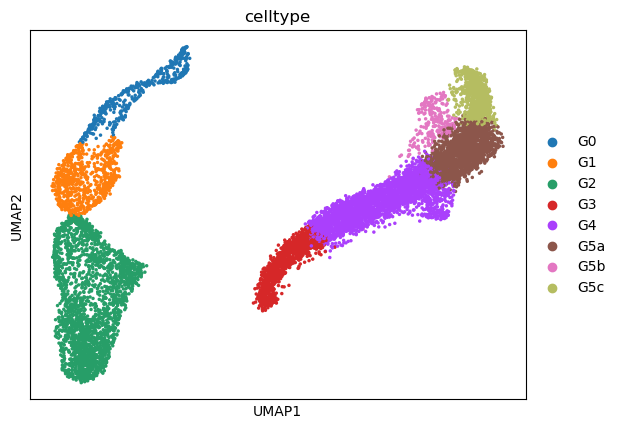

In [3]:
DATASET = "Ffar2"
normal_condition="WT"
compare_condition="KO"

versao = f"08sx.scNeu{DATASET}"

celltype_col="celltype"
condition_col="condition"
sample_col="sample"
id_col="sample"
counts_layer="QC_filtered"
design_col="condition"

out_dir = Path(f"/media/tahila/DADOS/HD/2605_scNeu/scNeu{DATASET}")
out_dir.mkdir(exist_ok=True)

adata_file_dir = Path(f"{out_dir}/06sx.Neu{DATASET}_annotated.h5ad")

save_plot_dir = Path(f"{out_dir}/{versao}_scenic")
save_plot_dir.mkdir(exist_ok=True)

adata = sc.read(adata_file_dir)

sc.pl.umap(adata, color="celltype", frameon=True, size=25)

# Download SCENIC resources



SCENIC requires three external resources:

1. A list of transcription factors used during gene regulatory network inference.
2. Gene-ranking databases used by cisTarget to evaluate motif enrichment.
3. A motif annotation table linking DNA-binding motifs to transcription factors.

Two ranking databases are downloaded:

* A promoter-proximal database covering 500 bp upstream and 100 bp downstream of the transcription start site.
* A broader database covering 10 kb upstream and 10 kb downstream of the transcription start site.

Using both databases allows cisTarget to evaluate motif enrichment across two regulatory search spaces. However, motif enrichment is computational evidence of a possible regulatory relationship and does not prove direct TF binding or causal regulation [Aibar, 2017; Van de Sande, 2020].

The resources are downloaded only when they are not already present in the output directory.

In [9]:
from __future__ import annotations

from pathlib import Path
from urllib.request import urlretrieve


def DownloadScenicResources(
    species: str,
    out_dir: str | Path,
) -> tuple[Path, list[str], list[Path], Path]:
    """
    Download the TF list, cisTarget ranking databases,
    and motif annotations required by pySCENIC.
    """

    species = species.lower()
    out_dir = Path(out_dir)

    # Create the output directory
    out_dir.mkdir(parents=True, exist_ok=True)

    base_url = "https://resources.aertslab.org/cistarget"

    # Define species-specific resources
    if species == "mouse":
        tf_url = (
            f"{base_url}/tf_lists/allTFs_mm.txt"
        )

        promoter_db_url = (
            f"{base_url}/databases/mus_musculus/mm10/"
            "refseq_r80/mc_v10_clust/gene_based/"
            "mm10_500bp_up_100bp_down_full_tx_v10_clust."
            "genes_vs_motifs.rankings.feather"
        )

        extended_db_url = (
            f"{base_url}/databases/mus_musculus/mm10/"
            "refseq_r80/mc_v10_clust/gene_based/"
            "mm10_10kbp_up_10kbp_down_full_tx_v10_clust."
            "genes_vs_motifs.rankings.feather"
        )

        motif_url = (
            f"{base_url}/motif2tf/"
            "motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl"
        )

    elif species == "human":
        tf_url = (
            f"{base_url}/tf_lists/allTFs_hg38.txt"
        )

        promoter_db_url = (
            f"{base_url}/databases/homo_sapiens/hg38/"
            "refseq_r80/mc_v10_clust/gene_based/"
            "hg38_500bp_up_100bp_down_full_tx_v10_clust."
            "genes_vs_motifs.rankings.feather"
        )

        extended_db_url = (
            f"{base_url}/databases/homo_sapiens/hg38/"
            "refseq_r80/mc_v10_clust/gene_based/"
            "hg38_10kbp_up_10kbp_down_full_tx_v10_clust."
            "genes_vs_motifs.rankings.feather"
        )

        motif_url = (
            f"{base_url}/motif2tf/"
            "motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl"
        )

    else:
        raise ValueError(
            "`species` must be either 'mouse' or 'human'."
        )

    urls = [
        tf_url,
        promoter_db_url,
        extended_db_url,
        motif_url,
    ]

    downloaded_paths = []

    # Download each file only when it does not already exist
    for url in urls:
        file_path = out_dir / url.split("/")[-1]

        if file_path.exists():
            print(f"File already exists: {file_path.name}")
        else:
            print(f"Downloading: {file_path.name}")
            urlretrieve(url, file_path)

        downloaded_paths.append(file_path)

    tf_path = downloaded_paths[0]

    ranking_db_paths = [
        downloaded_paths[1],
        downloaded_paths[2],
    ]

    motif_path = downloaded_paths[3]

    # Read the TF names
    with open(tf_path) as file:
        tfs = [line.strip() for line in file if line.strip()]

    print(f"\nDownloaded resources for: {species}")
    print(f"Number of TFs: {len(tfs)}")
    print(f"Number of ranking databases: {len(ranking_db_paths)}")

    return tf_path, tfs, ranking_db_paths, motif_path

In [10]:
tf_path, tfs, ranking_db_paths, motif_path = DownloadScenicResources(
    species="mouse",
    out_dir="/home/tahila/0.resources/scenic",
)

print(tf_path)
print(ranking_db_paths)
print(motif_path)
print(tfs[:10])

File already exists: allTFs_mm.txt
File already exists: mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather
File already exists: mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather
File already exists: motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl

Downloaded resources for: mouse
Number of TFs: 1860
Number of ranking databases: 2
/home/tahila/0.resources/scenic/allTFs_mm.txt
[PosixPath('/home/tahila/0.resources/scenic/mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather'), PosixPath('/home/tahila/0.resources/scenic/mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather')]
/home/tahila/0.resources/scenic/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl
['Bcl6b', 'Zscan26', 'Mtf1', 'Klf9', 'Zic5', 'Zfp410', 'Zfp3', 'Zfp691', 'Zfp637', 'Egr3']


## Validate SCENIC resources



Before preparing the expression matrix, the downloaded SCENIC resources were validated.

This step checks whether:

* The transcription factor list exists and contains valid gene names.
* The motif annotation file exists and can be read.
* The cisTarget ranking databases exist and can be opened by `ctxcore`.
* The ranking databases contain gene identifiers.
* Transcription factors from the TF list are represented in the ranking databases.

This validation is useful because the `ctx` step can take a long time and may fail when the ranking databases, motif annotations, or gene identifiers are incompatible.

The cisTarget ranking databases contain genes ranked according to regulatory motif evidence. They are used after gene regulatory network inference to identify TF–target modules with motif enrichment [Van de Sande, 2020].

This is a technical validation of the files. It does not confirm that the inferred regulatory relationships are biologically correct.


In [11]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
from ctxcore.rnkdb import FeatherRankingDatabase


def ValidateScenicResources(
    species: str,
    tf_path: str | Path,
    ranking_db_paths: list[str | Path],
    motif_path: str | Path,
) -> pd.DataFrame:
    """
    Validate the files required by pySCENIC.

    The function checks file existence, reads the TF list,
    opens each cisTarget database, and calculates the overlap
    between the TF list and the genes present in each database.
    """

    species = species.lower()

    if species not in ["mouse", "human"]:
        raise ValueError(
            "`species` must be either 'mouse' or 'human'."
        )

    tf_path = Path(tf_path)
    motif_path = Path(motif_path)
    ranking_db_paths = [Path(path) for path in ranking_db_paths]

    # Check whether the TF file exists
    if not tf_path.exists():
        raise FileNotFoundError(
            f"TF file not found: {tf_path}"
        )

    # Check whether the motif annotation file exists
    if not motif_path.exists():
        raise FileNotFoundError(
            f"Motif annotation file not found: {motif_path}"
        )

    # Read the transcription factor list
    with open(tf_path) as file:
        tfs = [
            line.strip()
            for line in file
            if line.strip()
        ]

    if len(tfs) == 0:
        raise ValueError(
            "The transcription factor list is empty."
        )

    # Remove duplicated TF names
    unique_tfs = set(tfs)

    print(f"Number of TFs: {len(tfs)}")
    print(f"Unique TFs: {len(unique_tfs)}")

    if len(tfs) != len(unique_tfs):
        print(
            f"Warning: {len(tfs) - len(unique_tfs)} "
            "duplicated TF names were found."
        )

    # Check whether the motif annotation table can be read
    motif_annotations = pd.read_csv(
        motif_path,
        sep="\t",
    )

    if motif_annotations.empty:
        raise ValueError(
            "The motif annotation table is empty."
        )

    print(
        f"Motif annotations: "
        f"{motif_annotations.shape[0]} rows"
    )

    validation_results = []

    # Validate each cisTarget ranking database
    for db_path in ranking_db_paths:

        if not db_path.exists():
            raise FileNotFoundError(
                f"Ranking database not found: {db_path}"
            )

        if not db_path.name.endswith(
            ".genes_vs_motifs.rankings.feather"
        ):
            print(
                f"Warning: unexpected database filename: "
                f"{db_path.name}"
            )

        # Open the database using ctxcore
        database = FeatherRankingDatabase(
            str(db_path),
            name=db_path.stem,
        )

        # Get the genes available in the database
        database_genes = set(database.genes)

        # Calculate TF overlap
        tfs_in_database = unique_tfs.intersection(
            database_genes
        )

        overlap_percentage = (
            len(tfs_in_database)
            / len(unique_tfs)
            * 100
        )

        validation_results.append(
            {
                "database": db_path.name,
                "n_genes": len(database_genes),
                "n_tfs_in_database": len(tfs_in_database),
                "tf_overlap_percentage": overlap_percentage,
            }
        )

    validation_results = pd.DataFrame(
        validation_results
    )

    print("\nSCENIC resource validation completed.")

    return validation_results

In [12]:
resource_validation = ValidateScenicResources(
    species="mouse",
    tf_path=tf_path,
    ranking_db_paths=ranking_db_paths,
    motif_path=motif_path,
)

resource_validation

Number of TFs: 1860
Unique TFs: 1860
Motif annotations: 252126 rows

SCENIC resource validation completed.


/tmp/ipykernel_53040/2758799272.py:72: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  motif_annotations = pd.read_csv(


,database,n_genes,n_tfs_in_database,tf_overlap_percentage
0,mm10_500bp_up_100bp_down_full_tx_v10_clust.gen...,24068,1738,93.44086
1,mm10_10kbp_up_10kbp_down_full_tx_v10_clust.gen...,24130,1738,93.44086


**How to interpret the TF overlap**

A high overlap indicates that most transcription factors from the TF list are represented among the genes ranked in the cisTarget database.

A lower overlap can indicate:

Different gene identifier systems.
Ensembl IDs instead of gene symbols.
Species incompatibility.
Differences between gene annotation versions.
Outdated or incomplete TF lists.

The overlap does not mean that all these TFs will generate regulons. It only means that they are available for the following SCENIC steps. Regulon inference also depends on their expression, their associations with target genes and motif enrichment [Aibar, 2017; Van de Sande, 2020].

# Step 1 - Prepare the expression data for SCENIC



The expression matrix used by SCENIC was obtained from an explicit count layer of the AnnData object. Integrated, scaled, imputed, PCA or Harmony representations should not be used because GRNBoost2 infers TF–target associations directly from gene expression variation across cells.

Genes with very low expression were removed before network inference. Following the SCENIC protocol, a gene was retained when:

* It was detected in at least 1% of the selected cells.
* Its total expression was at least three counts multiplied by 1% of the number of cells.

This filtering removes genes with insufficient information for reliable network inference and reduces computational cost. The analysis was not restricted to highly variable genes because transcription factors and biologically relevant target genes may not be classified as highly variable.

This step prepares a new AnnData object and does not modify the original object [Aibar, 2017; Van de Sande, 2020].


In [48]:
import numpy as np
from scipy import sparse


def PrepareScenicInput(
    adata,
    counts_layer,
    *,
    sample_key=None,
    samples=None,
    tfs=None,
    min_cell_fraction=0.01,
):
    """
    Prepare a count matrix for pySCENIC.

    The function selects cells, copies the count layer to `.X`,
    and removes genes with very low expression.

    ### Use uma camada com valores de expressão não negativos e em escala de contagem como a counts!
    """

    # Check whether the selected layer exists
    if counts_layer not in adata.layers:
        raise ValueError(
            f"Layer '{counts_layer}' was not found in adata.layers."
        )

    # Check the filtering fraction
    if not 0 < min_cell_fraction <= 1:
        raise ValueError(
            "`min_cell_fraction` must be between 0 and 1."
        )

    # Select specific samples when requested
    if samples is not None:

        if sample_key is None:
            raise ValueError(
                "`sample_key` must be provided when using `samples`."
            )

        if sample_key not in adata.obs:
            raise ValueError(
                f"Column '{sample_key}' was not found in adata.obs."
            )

        cell_mask = adata.obs[sample_key].isin(samples)
        adata_scenic = adata[cell_mask].copy()

    else:
        # Use all cells
        adata_scenic = adata.copy()

    if adata_scenic.n_obs == 0:
        raise ValueError(
            "No cells were selected for the SCENIC analysis."
        )

    # SCENIC requires unique gene names
    if not adata_scenic.var_names.is_unique:
        raise ValueError(
            "Gene names are not unique. Resolve duplicated gene "
            "names before running SCENIC."
        )

    # Use the selected count layer as the expression matrix
    adata_scenic.X = adata_scenic.layers[counts_layer].copy()

    # Check that the expression matrix contains non-negative values
    if sparse.issparse(adata_scenic.X):
        if adata_scenic.X.data.size > 0:
            minimum_value = adata_scenic.X.data.min()
        else:
            minimum_value = 0
    else:
        minimum_value = np.asarray(adata_scenic.X).min()

    if minimum_value < 0:
        raise ValueError(
            "The selected layer contains negative values. "
            "Use a non-negative count matrix."
        )

    # Calculate the SCENIC gene-filtering thresholds
    ## calculate the minimum number of cells a gene must be expressed in, according to the specified fraction
    min_cells = max(
        1,
        int(np.ceil(adata_scenic.n_obs * min_cell_fraction)),
    )

    min_total_counts = 3 * min_cells

    # Calculate gene detection and total expression
    if sparse.issparse(adata_scenic.X):

        cells_per_gene = np.asarray(
            (adata_scenic.X > 0).sum(axis=0)
        ).ravel()

        counts_per_gene = np.asarray(
            adata_scenic.X.sum(axis=0)
        ).ravel()

    else:
        expression_matrix = np.asarray(adata_scenic.X)

        cells_per_gene = (
            expression_matrix > 0
        ).sum(axis=0)

        counts_per_gene = expression_matrix.sum(axis=0)

    # Keep genes passing both SCENIC filters
    gene_mask = (
        (cells_per_gene >= min_cells)
        & (counts_per_gene >= min_total_counts)
    )

    n_genes_before = adata_scenic.n_vars

    adata_scenic = adata_scenic[:, gene_mask].copy()

    print(f"Cells selected: {adata_scenic.n_obs}")
    print(f"Minimum cells per gene: {min_cells}")
    print(f"Minimum total counts per gene: {min_total_counts}")
    print(
        f"Genes retained: {adata_scenic.n_vars} "
        f"of {n_genes_before}"
    )

    # Report how many TFs are present after filtering
    if tfs is not None:
        tfs_found = adata_scenic.var_names.isin(tfs).sum()

        print(
            f"TFs retained: {tfs_found} of {len(tfs)}"
        )

    return adata_scenic

In [14]:
adata_scenic = PrepareScenicInput(
    adata,
    counts_layer="QC_filtered", 
    sample_key="sample",
    samples=None,
    tfs=tfs,
)

adata_scenic

Cells selected: 10570
Minimum cells per gene: 106
Minimum total counts per gene: 318
Genes retained: 10272 of 27992
TFs retained: 903 of 1860


AnnData object with n_obs × n_vars = 10570 × 10272
    obs: 'sample', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'doublet_score', 'predicted_doublet', 'is_doublet', 'leiden_res0.3', 'leiden_res0.4', 'leiden_res0.5', 'leiden_res0.6', 'leiden_res0.8', 'score_G0', 'score_G1', 'score_G2', 'score_G3', 'score_G4', 'score_G5a', 'score_G5b', 'score_G5c', 'aucell_G0', 'aucell_G1', 'aucell_G2', 'aucell_G3', 'aucell_G4', 'aucell_G5a', 'aucell_G5b', 'aucell_G5c', 'celltype'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'used_for_pca'
    uns: 'celltype_colors', 'hvg', 'leiden_res0.8_colors', 'log1p', 'neighbors', 'pca', 'qc_params', 'rank_gene

In [15]:
# A .X do novo objeto deve conter a camada selecionada:
adata_scenic.X

<10570x10272 sparse matrix of type '<class 'numpy.float32'>'
	with 24107228 stored elements in Compressed Sparse Row format>

In [16]:
# O objeto original permanece inalterado:
adata

AnnData object with n_obs × n_vars = 10570 × 27992
    obs: 'sample', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'doublet_score', 'predicted_doublet', 'is_doublet', 'leiden_res0.3', 'leiden_res0.4', 'leiden_res0.5', 'leiden_res0.6', 'leiden_res0.8', 'score_G0', 'score_G1', 'score_G2', 'score_G3', 'score_G4', 'score_G5a', 'score_G5b', 'score_G5c', 'aucell_G0', 'aucell_G1', 'aucell_G2', 'aucell_G3', 'aucell_G4', 'aucell_G5a', 'aucell_G5b', 'aucell_G5c', 'celltype'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'used_for_pca'
    uns: 'celltype_colors', 'hvg', 'leiden_res0.8_colors', 'log1p', 'neighbors', 'pca', 'qc_params', 'rank_gene

## Export the SCENIC expression matrix



A .loom file stores the expression matrix with genes as rows and cells as columns. This orientation is expected by the pySCENIC command-line workflow. The export does not normalize, transform or filter the data again; it only saves the matrix prepared in the previous step [Van de Sande, 2020].

loompy supports sparse matrices, so the expression matrix does not need to be converted to a dense array, which would consume much more memory.

The filtered count matrix was exported to a loom file for use with the pySCENIC command-line interface.

AnnData stores the expression matrix as cells × genes, while the loom file used by pySCENIC stores genes × cells. Therefore, the matrix was transposed during export.

The loom file contains:

* `Gene`: gene symbols stored as row attributes.
* `CellID`: cell identifiers stored as column attributes.
* `nGene`: number of detected genes in each cell.
* `nUMI`: total number of counts in each cell.

This step only changes the file format. It does not perform normalization, integration or additional gene filtering [Aibar, 2017; Van de Sande, 2020].


In [53]:
from pathlib import Path

import loompy
import numpy as np
from scipy import sparse


def ExportScenicLoom(
    adata_scenic,
    loom_path,
    *,
    overwrite=False,
):
    """
    Export a prepared AnnData object to a loom file for pySCENIC.

    The AnnData matrix is expected to contain cells as rows and genes
    as columns. It is transposed during export because loom files store
    genes as rows and cells as columns.
    """

    loom_path = Path(loom_path)

    # Create the output directory
    loom_path.parent.mkdir(parents=True, exist_ok=True)

    # Avoid replacing an existing file by accident
    if loom_path.exists():
        if not overwrite:
            print(f"File already exists: {loom_path}")
            return loom_path

        loom_path.unlink()

    # Check that the object contains cells and genes
    if adata_scenic.n_obs == 0:
        raise ValueError("The AnnData object contains no cells.")

    if adata_scenic.n_vars == 0:
        raise ValueError("The AnnData object contains no genes.")

    # SCENIC requires unique gene and cell names
    if not adata_scenic.var_names.is_unique:
        raise ValueError("Gene names must be unique.")

    if not adata_scenic.obs_names.is_unique:
        raise ValueError("Cell names must be unique.")

    expression_matrix = adata_scenic.X

    # Calculate cell-level count information
    if sparse.issparse(expression_matrix):
        n_genes = np.asarray(
            (expression_matrix > 0).sum(axis=1)
        ).ravel()

        n_umi = np.asarray(
            expression_matrix.sum(axis=1)
        ).ravel()

        # Loom stores genes as rows and cells as columns
        loom_matrix = expression_matrix.T.tocsc()

    else:
        expression_matrix = np.asarray(expression_matrix)

        n_genes = (expression_matrix > 0).sum(axis=1)
        n_umi = expression_matrix.sum(axis=1)

        # Loom stores genes as rows and cells as columns
        loom_matrix = expression_matrix.T

    # Gene information
    row_attributes = {
        "Gene": np.asarray(
            adata_scenic.var_names,
            dtype=str,
        )
    }

    # Cell information
    column_attributes = {
        "CellID": np.asarray(
            adata_scenic.obs_names,
            dtype=str,
        ),
        "nGene": n_genes,
        "nUMI": n_umi,
    }

    # Create the loom file
    loompy.create(
        str(loom_path),
        loom_matrix,
        row_attributes,
        column_attributes,
    )

    print(f"Loom file created: {loom_path}")
    print(
        f"Matrix shape: {adata_scenic.n_vars} genes × "
        f"{adata_scenic.n_obs} cells"
    )

    return loom_path

In [18]:
loom_path = ExportScenicLoom(
    adata_scenic,
    loom_path="/media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/input/scenic_input.loom",
)

File already exists: /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/input/scenic_input.loom


In [19]:
with loompy.connect(str(loom_path), mode="r") as loom:
    print("Loom shape:", loom.shape)
    print("First genes:", loom.ra["Gene"][:5])
    print("First cells:", loom.ca["CellID"][:5])
    

Loom shape: (10272, 10570)
First genes: ['0610009B22Rik' '0610012G03Rik' '0610030E20Rik' '0610040J01Rik'
 '1110002L01Rik']
First cells: ['106988-K1' '155169-K1' '165809-K1' '216472-K1' '247465-K1']


# Step 2 - Infer candidate TF–target associations



The first analytical step of pySCENIC infers candidate associations between transcription factors and target genes using GRNBoost2.

For each gene, GRNBoost2 fits a separate gradient-boosting regression model in which:

* The target variable is the expression of the gene across cells.
* The predictors are the expression profiles of the transcription factors.
* The output is an importance score for each candidate TF–target association.

A higher importance score indicates that the transcription factor contributed more to predicting the expression profile of the target gene.

The importance score is not a correlation coefficient, does not indicate activation or repression, and does not demonstrate a direct or causal regulatory interaction. At this stage, the results represent expression-based candidate associations. The following cisTarget step will test whether these modules also have cis-regulatory motif support [Moerman, 2019; Van de Sande, 2020].

Because GRNBoost2 uses stochastic gradient boosting, a fixed random seed was used to improve reproducibility. Small differences may still occur across software versions or computing environments [Moerman, 2019].

The [official pySCENIC command](https://pyscenic.readthedocs.io/en/latest/installation.html) uses the expression matrix and the species-specific TF list to generate an adjacency table.


In [1]:
from pathlib import Path
import shutil
import subprocess


def RunScenicGrn(
    loom_path,
    tf_path,
    output_dir,
    *,
    num_workers=3,
    seed=42,
    overwrite=False,
):
    """
    Run the GRNBoost2 step of pySCENIC.

    This step infers candidate TF-target associations from
    gene expression patterns across cells.
    """

    loom_path = Path(loom_path)
    tf_path = Path(tf_path)
    output_dir = Path(output_dir)

    # Check the input files
    if not loom_path.exists():
        raise FileNotFoundError(
            f"Loom file not found: {loom_path}"
        )

    if not tf_path.exists():
        raise FileNotFoundError(
            f"TF list not found: {tf_path}"
        )

    # Check whether pySCENIC is available
    if shutil.which("pyscenic") is None:
        raise RuntimeError(
            "The 'pyscenic' command was not found in the current environment."
        )

    # Create the output directory
    output_dir.mkdir(parents=True, exist_ok=True)

    adjacency_path = output_dir / "adjacencies.tsv"

    # Avoid running the analysis again by accident
    if adjacency_path.exists() and not overwrite:
        print(f"File already exists: {adjacency_path}")
        return adjacency_path

    command = [
        "pyscenic",
        "grn",
        str(loom_path),
        str(tf_path),
        "--method",
        "grnboost2",
        "--output",
        str(adjacency_path),
        "--num_workers",
        str(num_workers),
        "--seed",
        str(seed),
    ]

    print("Running GRNBoost2...")
    print(" ".join(command))

    # Run pySCENIC and show its output in the notebook
    subprocess.run(
        command,
        check=True,
    )

    if not adjacency_path.exists():
        raise RuntimeError(
            "GRNBoost2 finished without creating the adjacency file."
        )

    print(f"\nAdjacency file created: {adjacency_path}")

    return adjacency_path

In [21]:
from pathlib import Path

scenic_dir = Path(
    "/media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/"
    "08sx.scNeuFfar2_scenic"
)

output_dir = scenic_dir / "output"

adjacency_path = RunScenicGrn(
    loom_path=loom_path,
    tf_path=tf_path,
    output_dir=output_dir,
    num_workers=3,
    seed=42,
)

Running GRNBoost2...
pyscenic grn /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/input/scenic_input.loom /home/tahila/0.resources/scenic/allTFs_mm.txt --method grnboost2 --output /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/adjacencies.tsv --num_workers 3 --seed 42


/home/tahila/miniconda3/envs/scenic_env/lib/python3.8/site-packages/loompy/bus_file.py:68: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def twobit_to_dna(twobit: int, size: int) -> str:
/home/tahila/miniconda3/envs/scenic_env/lib/python3.8/site-packages/loompy/bus_file.py:85: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def dna_to_twobit(dna: str) -> int:
/hom

preparing dask client
parsing input
creating dask graph
3 partitions
computing dask graph


/home/tahila/miniconda3/envs/scenic_env/lib/python3.8/site-packages/distributed/client.py:3108: UserWarning: Sending large graph of size 108.82 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


not shutting down client, client was created externally
finished



2026-08-05 18:25:36,387 - pyscenic.cli.pyscenic - INFO - Writing results to file.



Adjacency file created: /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/adjacencies.tsv


## Check the GRNBoost2 output


Step 6 — Check the GRNBoost2 output

Antes de executar o ctx, vamos apenas verificar se o arquivo foi produzido corretamente. Não vamos filtrar manualmente os top 5–10%, porque o próprio pySCENIC constrói os módulos usando diferentes critérios de importância, incluindo percentis e os principais alvos de cada TF.

The GRNBoost2 output was checked before motif enrichment analysis.

The adjacency table contains three main columns:

* `TF`: candidate transcription factor.

* `target`: candidate target gene.
* `importance`: contribution of the TF to the prediction of the target gene expression profile.

The importance score is non-negative and represents predictive importance. It is not a correlation coefficient, does not indicate activation or repression and does not demonstrate causal regulation.

No manual importance cutoff was applied at this stage. pySCENIC uses different importance thresholds and top-target criteria during module construction before the cisTarget motif enrichment step [Moerman, 2019; Van de Sande, 2020].

GRNBoost2 is a gradient-boosting-based method developed for scalable inference of candidate gene regulatory networks [Moerman, 2019].


In [22]:
from pathlib import Path

import numpy as np
import pandas as pd


def CheckScenicGrn(adjacency_path):
    """
    Read and validate the GRNBoost2 adjacency table.

    The function checks the expected columns and reports basic
    information about the inferred candidate TF-target associations.
    """

    adjacency_path = Path(adjacency_path)

    if not adjacency_path.exists():
        raise FileNotFoundError(
            f"Adjacency file not found: {adjacency_path}"
        )

    # Read the GRNBoost2 output
    adjacencies = pd.read_csv(
        adjacency_path,
        sep="\t",
    )

    required_columns = {"TF", "target", "importance"}

    if not required_columns.issubset(adjacencies.columns):
        raise ValueError(
            "The adjacency table must contain the columns: "
            "'TF', 'target', and 'importance'."
        )

    # Ensure that importance contains numeric values
    adjacencies["importance"] = pd.to_numeric(
        adjacencies["importance"],
        errors="coerce",
    )

    # Check missing or invalid values
    n_missing = adjacencies[
        ["TF", "target", "importance"]
    ].isna().any(axis=1).sum()

    n_invalid = (
        ~np.isfinite(adjacencies["importance"])
    ).sum()

    n_negative = (
        adjacencies["importance"] < 0
    ).sum()

    n_duplicates = adjacencies.duplicated(
        subset=["TF", "target"]
    ).sum()

    if n_missing > 0:
        raise ValueError(
            f"{n_missing} rows contain missing values."
        )

    if n_invalid > 0:
        raise ValueError(
            f"{n_invalid} importance values are not finite."
        )

    if n_negative > 0:
        raise ValueError(
            f"{n_negative} negative importance values were found."
        )

    print(f"Associations: {len(adjacencies):,}")
    print(f"Transcription factors: {adjacencies['TF'].nunique():,}")
    print(f"Target genes: {adjacencies['target'].nunique():,}")
    print(f"Duplicated TF-target pairs: {n_duplicates:,}")

    print("\nImportance summary:")
    print(
        adjacencies["importance"]
        .describe()
        .round(4)
    )

    return adjacencies

In [24]:
adjacencies = CheckScenicGrn(
    adjacency_path=adjacency_path,
)
adjacencies.sort_values(
    "importance",
    ascending=False,
).head(20)

Associations: 894,221
Transcription factors: 903
Target genes: 10,272
Duplicated TF-target pairs: 0

Importance summary:
count    894221.0000
mean          0.3848
std           0.9173
min           0.0000
25%           0.0255
50%           0.0704
75%           0.2703
max          30.3763
Name: importance, dtype: float64


,TF,target,importance
0,Rpl6,Rpl15,30.376285
1,Rpl6,Rpl18a,29.920029
2,Rpl6,Rps28,29.723568
3,Rpl6,Rpl19,29.207168
4,Rpl6,Rps24,29.091840
5,Rpl6,Rps23,28.989502
6,Rpl6,Snrpg,28.455396
7,Rpl6,Rps29,28.221424
8,Rpl6,Rps26,27.933631
9,Rpl6,Rps13,27.732705


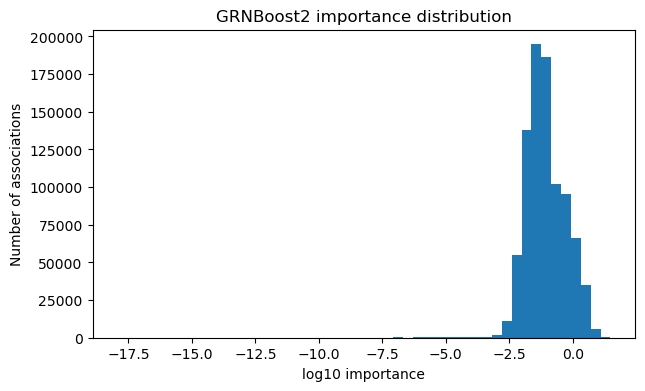

In [26]:
import matplotlib.pyplot as plt

# O log10 é usado apenas para visualizar melhor uma distribuição geralmente muito assimétrica. Ele não altera o arquivo nem é usado pelo ctx.
# Após esta verificação, o próximo passo será o RunScenicCtx, que usará os bancos cisTarget para manter módulos com suporte de motivos regulatórios.

plt.figure(figsize=(7, 4))

plt.hist(
    np.log10(adjacencies["importance"]),
    bins=50,
)

plt.xlabel("log10 importance")
plt.ylabel("Number of associations")
plt.title("GRNBoost2 importance distribution")

plt.show()

### How does GRNBoost2 inference works?

GRNBoost2 was used to infer candidate associations between transcription factors and target genes from the single-cell expression matrix.

The main question of GRNBoost2 is:

> Which transcription factors help predict the expression of each gene across cells?

For each target gene, GRNBoost2 builds a separate regression model. The expression of the target gene is used as the response variable, while the expression profiles of all available transcription factors are used as predictors [Moerman, 2019; Van de Sande, 2020].

For example, for the target gene `Il1b`, the model evaluates whether transcription factors such as `Cebpb`, `Stat1`, `Nfkb1` and `Jun` help predict the variation of `Il1b` expression across cells.

A simplified example is:

| Cell   | Cebpb | Stat1 | Il1b |
| ------ | ----: | ----: | ---: |
| Cell 1 |     0 |     0 |    0 |
| Cell 2 |     1 |     0 |    1 |
| Cell 3 |     3 |     0 |    4 |
| Cell 4 |     4 |     1 |    6 |
| Cell 5 |     5 |     0 |    8 |

In this example, `Il1b` expression increases when `Cebpb` expression increases. Therefore, `Cebpb` may receive a higher importance score than `Stat1` in the model used to predict `Il1b`.

The output may look like:

| TF    | target | importance |
| ----- | ------ | ---------: |
| Cebpb | Il1b   |       12.4 |
| Jun   | Il1b   |        4.8 |
| Stat1 | Il1b   |        0.3 |

The `importance` value represents how much each transcription factor contributed to predicting the expression of the target gene.

A higher importance score means:

> The expression of this TF was more useful for predicting the expression pattern of this target gene in this dataset.

However, the importance score is not:

* a correlation coefficient;
* a p-value;
* a measure of activation or repression;
* a direct estimate of biological effect;
* evidence of causal regulation.

For example, an association such as:

`Cebpb → Il1b`

does not prove that CEBPB directly binds to the regulatory region of `Il1b`. Both genes may respond to the same inflammatory stimulus:

`Inflammatory stimulus → Cebpb`

`Inflammatory stimulus → Il1b`

In this situation, `Cebpb` may help predict `Il1b`, even if the relationship is indirect.

Another possibility is the presence of an intermediate gene:

`Cebpb → Gene X → Il1b`

GRNBoost2 may identify an association between `Cebpb` and `Il1b`, but expression data alone cannot determine whether the regulation is direct.

GRNBoost2 uses gradient-boosting regression trees. These models can evaluate several transcription factors at the same time and can capture non-linear relationships.

For example, a target gene may increase only when two transcription factors are expressed together:

`Cebpb high + Nfkb1 high → Il1b high`

A simple correlation between `Cebpb` and `Il1b` may not completely capture this combined effect. GRNBoost2 can model this type of relationship because it uses multiple decision trees and combines their predictions [Moerman, 2019].

The analysis is repeated for each target gene in the expression matrix. Therefore, different models are generated for genes such as:

* `Il1b`;
* `Cxcl2`;
* `Mmp8`;
* `Fos`;
* `Dusp1`;
* and all other genes retained after filtering.

The final `adjacencies.tsv` file represents a candidate regulatory network:

`TF → target gene`

Each row contains:

* the candidate transcription factor;
* the candidate target gene;
* the predictive importance score.

At this stage, the network is based only on gene expression patterns. It does not yet include evidence that the target genes contain regulatory motifs associated with the transcription factor.

The next SCENIC step, cisTarget, evaluates whether the candidate target genes of each TF are enriched for DNA-binding motifs associated with that TF. This step helps remove expression-based associations that do not have cis-regulatory motif support [Aibar, 2017; Van de Sande, 2020].

Therefore, the GRNBoost2 result should be interpreted as:

> A set of candidate TF-target associations inferred from expression variation across cells.

It should not yet be interpreted as:

> A set of experimentally confirmed direct regulatory interactions.


# Step 73 — Run cisTarget motif enrichment and regulon pruning

## Step 4 - cisTarget motif enrichment and regulon pruning

The GRNBoost2 result contains candidate TF–target associations inferred only from expression patterns. The `pyscenic ctx` step was used to evaluate whether these candidate associations also have cis-regulatory motif support.

This step performs three main operations:

1. It uses the expression matrix to calculate the correlation between each transcription factor and its candidate target genes.
2. It organizes the candidate TF–target associations into co-expression modules.
3. It uses cisTarget ranking databases to test whether the genes in each module are enriched for DNA-binding motifs associated with the same transcription factor.

For example, GRNBoost2 may identify 500 candidate genes associated with `Cebpb`. cisTarget then asks whether genes containing motifs associated with CEBPB tend to occur near the top of the motif-ranking database.

A simplified example is:

| Step             | Result                                                 |
| ---------------- | ------------------------------------------------------ |
| GRNBoost2        | 500 candidate genes associated with `Cebpb`            |
| Motif enrichment | CEBPB-related motifs are enriched in the module        |
| Regulon pruning  | 80 genes with the strongest motif support are retained |
| Final result     | `Cebpb` regulon containing 80 candidate direct targets |

If the genes associated with a TF do not show enrichment for a motif linked to that TF, the module is not retained as a regulon.

The genes retained after motif enrichment correspond mainly to the leading-edge genes responsible for the enrichment signal. These genes are considered candidate direct targets of the TF.

Therefore, this step changes the interpretation from:

> Expression-based TF–target association

to:

> Expression-based TF–target association with cis-regulatory motif support

However, motif enrichment does not prove that the TF physically binds to the regulatory region in the analyzed cells. The result remains a computationally inferred regulatory relationship and requires experimental validation to demonstrate direct binding or causal regulation [Aibar, 2017; Van de Sande, 2020].

The default pySCENIC behavior calculates TF–target correlations using all cells. Dropout masking was not enabled because the current default matches the behavior of the original R implementation of SCENIC. Default motif-enrichment and module-construction parameters were retained [Van de Sande, 2020].

The output of this step is a collection of regulons. Each regulon contains one transcription factor and its candidate target genes supported by motif enrichment. Regulon activity is not calculated in this step; it will be estimated per cell using AUCell in the next step.

The SCENIC workflow describes cisTarget as the stage that removes candidate indirect targets from the GRNBoost2 modules using cis-regulatory motif evidence [Aibar, 2017; Van de Sande, 2020]. ([Nature][1])

### Expected files

```text
output/
├── adjacencies.tsv
├── grnboost2.log
├── regulons.csv
└── ctx.log
```

O `ctx` pode mostrar avisos como:

```text
Less than 80% of the genes in ... could be mapped
```

Isso significa que um módulo específico não apresentou sobreposição suficiente com determinado banco cisTarget e foi ignorado para aquele banco. Alguns avisos desse tipo podem ocorrer normalmente; o ponto principal é verificar se `regulons.csv` foi criado e não está vazio. O pySCENIC ignora módulos com cobertura insuficiente no banco em vez de tratá-los automaticamente como regulons válidos. ([github.com][3])

[1]: https://www.nature.com/articles/s41596-020-0336-2 "A scalable SCENIC workflow for single-cell gene regulatory network analysis | Nature Protocols"
[2]: https://pyscenic.readthedocs.io/en/latest/installation.html "Installation and Usage — pySCENIC latest documentation"
[3]: https://github.com/aertslab/pySCENIC/issues/106?utm_source=chatgpt.com "prune2df warning messages #106 - aertslab/pySCENIC"


In [4]:
from pathlib import Path
import subprocess


def RunScenicCtx(
    adjacency_path,
    ranking_db_paths,
    motif_path,
    loom_path,
    output_dir,
    *,
    pyscenic_path="pyscenic",
    num_workers=3,
    overwrite=False,
):
    """
    Run the cisTarget step of pySCENIC.

    This step identifies TF-target modules supported by
    enrichment of regulatory motifs.
    """

    adjacency_path = Path(adjacency_path)
    ranking_db_paths = [Path(path) for path in ranking_db_paths]
    motif_path = Path(motif_path)
    loom_path = Path(loom_path)
    output_dir = Path(output_dir)

    # Check input files
    input_paths = [
        adjacency_path,
        motif_path,
        loom_path,
        *ranking_db_paths,
    ]

    for path in input_paths:
        if not path.exists():
            raise FileNotFoundError(f"File not found: {path}")

    output_dir.mkdir(parents=True, exist_ok=True)

    regulons_path = output_dir / "regulons.csv"
    log_path = output_dir / "ctx.log"

    # Avoid running the analysis again by accident
    if regulons_path.exists() and not overwrite:
        print(f"File already exists: {regulons_path}")
        return regulons_path

    command = [
        str(pyscenic_path),
        "ctx",
        str(adjacency_path),
        *[str(path) for path in ranking_db_paths],
        "--annotations_fname",
        str(motif_path),
        "--expression_mtx_fname",
        str(loom_path),
        "--mode",
        "custom_multiprocessing",
        "--output",
        str(regulons_path),
        "--num_workers",
        str(num_workers),
    ]

    print("Running cisTarget...")
    print(" ".join(command))

    result = subprocess.run(
        command,
        capture_output=True,
        text=True,
    )

    # Save the command output for troubleshooting
    log_path.write_text(
        "COMMAND\n"
        + " ".join(command)
        + "\n\nSTDOUT\n"
        + result.stdout
        + "\n\nSTDERR\n"
        + result.stderr
    )

    if result.returncode != 0:
        print(result.stderr)

        raise RuntimeError(
            f"cisTarget failed. Check the log file:\n{log_path}"
        )

    if not regulons_path.exists():
        raise RuntimeError(
            "cisTarget finished without creating the regulon file."
        )

    if regulons_path.stat().st_size == 0:
        raise RuntimeError(
            "cisTarget created an empty regulon file."
        )

    print(f"\nRegulon file created: {regulons_path}")
    print(f"Log file created: {log_path}")

    return regulons_path

In [29]:
regulons_path = RunScenicCtx(
    adjacency_path=adjacency_path,
    ranking_db_paths=ranking_db_paths,
    motif_path=motif_path,
    loom_path=loom_path,
    output_dir=output_dir,
    num_workers=3,
)

Running cisTarget...
pyscenic ctx /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/adjacencies.tsv /home/tahila/0.resources/scenic/mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather /home/tahila/0.resources/scenic/mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather --annotations_fname /home/tahila/0.resources/scenic/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl --expression_mtx_fname /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/input/scenic_input.loom --mode custom_multiprocessing --output /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/regulons.csv --num_workers 3

Regulon file created: /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/regulons.csv
Log file created: /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/ctx.log


# Step 5 — Calculate regulon activity with AUCell



### AUCell regulon activity

After the regulons were defined by cisTarget, AUCell was used to calculate the activity of each regulon in each individual cell.

For every cell, AUCell ranks all genes from the highest to the lowest expression. It then checks whether the target genes of a regulon are concentrated near the top of this ranking.

For example, consider a `Cebpb` regulon containing the following target genes:

* `Il1b`
* `Cxcl2`
* `Nfkbiz`
* `Plaur`
* `Dusp1`

In a cell where several of these genes are highly expressed, they will appear near the top of the gene ranking and the `Cebpb` regulon will receive a high AUC score.

In another cell where these genes have low or no expression, they will appear lower in the ranking and the regulon will receive a low AUC score.

A simplified example is:

| Cell   | Genes near the top of the ranking  | Cebpb regulon AUC |
| ------ | ---------------------------------- | ----------------: |
| Cell 1 | `Il1b`, `Cxcl2`, `Nfkbiz`, `Plaur` |              High |
| Cell 2 | `Il1b`, `Dusp1`                    |      Intermediate |
| Cell 3 | None of the regulon targets        |               Low |

The `auc_threshold` parameter defines the fraction of the ranked genes used to calculate the recovery curve. With `auc_threshold=0.05`, AUCell evaluates the top 5% of genes in each cell.

For a matrix containing 10,272 genes, this corresponds to approximately:

[
10,272 \times 0.05 \approx 514 \text{ genes}
]

Therefore, AUCell evaluates whether the regulon target genes are enriched among approximately the 514 highest-ranked genes in each cell.

The resulting AUC value is a relative regulon activity score. It is not a p-value, a probability, a conventional ROC AUC or a direct measurement of TF protein activity. A high score indicates that many target genes of the regulon are highly ranked in that cell [Aibar, 2017; Van de Sande, 2020].

Because AUCell uses gene rankings within each cell, it is less affected by differences in sequencing depth than methods based directly on raw expression sums. However, its results still depend on gene detection, regulon size and the quality of the inferred regulons [Aibar, 2017; Van de Sande, 2020]. The official pySCENIC workflow applies AUCell after GRN inference and cisTarget pruning to generate a cell × regulon activity matrix. ([pySCENIC][1])

O arquivo `aucell_output.loom` conterá a matriz de atividade com:

```text
cells × regulons
```

incorporada aos atributos do loom. O uso de `--seed` no AUCell é suportado oficialmente para melhorar a reprodutibilidade do ranqueamento quando existem genes empatados. ([pySCENIC][2])

[1]: https://pyscenic.readthedocs.io/en/latest/tutorial.html "Tutorial — pySCENIC latest documentation"
[2]: https://pyscenic.readthedocs.io/en/latest/releasenotes.html?utm_source=chatgpt.com "Release Notes — pySCENIC latest documentation"


In [38]:
from pathlib import Path
import subprocess


def RunScenicAucell(
    loom_path,
    regulons_path,
    output_dir,
    *,
    pyscenic_path="pyscenic",
    num_workers=3,
    auc_threshold=0.05,
    seed=42,
    overwrite=False,
):
    """
    Calculate regulon activity in each cell using AUCell.

    AUCell ranks genes within each cell and evaluates whether
    the target genes of each regulon are enriched near the top
    of the ranking.
    """

    loom_path = Path(loom_path)
    regulons_path = Path(regulons_path)
    output_dir = Path(output_dir)

    # Check input files
    if not loom_path.exists():
        raise FileNotFoundError(
            f"Loom file not found: {loom_path}"
        )

    if not regulons_path.exists():
        raise FileNotFoundError(
            f"Regulon file not found: {regulons_path}"
        )

    output_dir.mkdir(parents=True, exist_ok=True)

    aucell_path = output_dir / "aucell_output.loom"
    log_path = output_dir / "aucell.log"

    # Avoid running AUCell again by accident
    if aucell_path.exists() and not overwrite:
        print(f"File already exists: {aucell_path}")
        return aucell_path

    command = [
        str(pyscenic_path),
        "aucell",
        str(loom_path),
        str(regulons_path),
        "--output",
        str(aucell_path),
        "--num_workers",
        str(num_workers),
        "--auc_threshold",
        str(auc_threshold),
        "--seed",
        str(seed),
    ]

    print("Running AUCell...")
    print(" ".join(command))

    result = subprocess.run(
        command,
        capture_output=True,
        text=True,
    )

    # Save the command output
    log_path.write_text(
        "COMMAND\n"
        + " ".join(command)
        + "\n\nSTDOUT\n"
        + result.stdout
        + "\n\nSTDERR\n"
        + result.stderr
    )

    if result.returncode != 0:
        print(result.stderr)

        raise RuntimeError(
            f"AUCell failed. Check the log file:\n{log_path}"
        )

    if not aucell_path.exists():
        raise RuntimeError(
            "AUCell finished without creating the output file."
        )

    print(f"\nAUCell output created: {aucell_path}")
    print(f"Log file created: {log_path}")

    return aucell_path

In [ ]:
aucell_path = RunScenicAucell(
    loom_path=loom_path,
    regulons_path=regulons_path,
    output_dir=output_dir,
    num_workers=3,
    auc_threshold=0.05,
    seed=42,
)

# Um detalhe importante: o seu parâmetro: auc_threshold=0.05 não é um cutoff para declarar o regulon ativo. 
# Ele informa ao AUCell que o score deve ser calculado considerando a recuperação dos genes do regulon dentro dos 5% superiores do ranking de expressão de cada célula [Aibar, 2017; Van de Sande, 2020].

Running AUCell...
pyscenic aucell /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/input/scenic_input.loom /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/regulons.csv --output /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/aucell_output.loom --num_workers 3 --auc_threshold 0.05 --seed 42

AUCell output created: /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/aucell_output.loom
Log file created: /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/aucell.log


## Read and inspect the AUCell results

The final core output of pySCENIC is a cell-by-regulon activity matrix generated by AUCell.

For each cell, AUCell ranks genes according to their expression and evaluates whether the target genes of each regulon are concentrated near the top of this ranking. A higher AUC score indicates that a larger fraction of the regulon target genes is highly ranked in that cell.

The `auc_threshold=0.05` parameter used during AUCell defines the fraction of the gene ranking used to calculate the enrichment score. It does not define whether a regulon is active or inactive.

The resulting AUC matrix can be used to:

* Examine the activity distribution of individual regulons.
* Visualize regulon activity on a UMAP.
* Generate heatmaps across cells or cell populations.
* Cluster cells according to shared regulatory activity.

These analyses use the official AUCell output but are downstream visualization and interpretation steps rather than additional regulatory network inference [Aibar, 2017; Van de Sande, 2020].

In [54]:
from pathlib import Path

import loompy
import pandas as pd


def ReadScenicAucell(aucell_path):
    """
    Read the cell-by-regulon AUCell activity matrix
    from the pySCENIC output loom file.
    """

    aucell_path = Path(aucell_path)

    if not aucell_path.exists():
        raise FileNotFoundError(
            f"AUCell file not found: {aucell_path}"
        )

    with loompy.connect(
        str(aucell_path),
        mode="r",
        validate=False,
    ) as loom:

        # Check the required loom attributes
        if "CellID" not in loom.ca.keys():
            raise ValueError(
                "The loom file does not contain 'CellID'."
            )

        if "RegulonsAUC" not in loom.ca.keys():
            raise ValueError(
                "The loom file does not contain 'RegulonsAUC'."
            )

        cell_ids = loom.ca["CellID"].astype(str)
        auc_data = loom.ca["RegulonsAUC"]

    # RegulonsAUC is normally stored as a structured array
    if auc_data.dtype.names is None:
        raise ValueError(
            "Regulon names could not be read from 'RegulonsAUC'."
        )

    auc_matrix = pd.DataFrame(
        {
            regulon: auc_data[regulon].astype(float)
            for regulon in auc_data.dtype.names
        },
        index=cell_ids,
    )

    auc_matrix.index.name = "CellID"

    print(f"Cells: {auc_matrix.shape[0]}")
    print(f"Regulons: {auc_matrix.shape[1]}")

    return auc_matrix

In [ ]:
## Read the result
auc_matrix = ReadScenicAucell(
    aucell_path=aucell_path,
)

# Visualize the beginning of the matrix:
display(auc_matrix.head())

# Check its dimensions:
display(auc_matrix.shape)

# List the regulons:
display(auc_matrix.columns.tolist())


Cells: 10570
Regulons: 199


,Arid3a(+),Arnt(+),Atf1(+),Atf2(+),Atf3(+),Atf4(+),Bach1(+),Bcl11a(+),Bclaf1(+),Bhlhe40(+),...,Zfp712(+),Zfp768(+),Zfp770(+),Zfp790(+),Zfp87(+),Zfp994(+),Zgpat(+),Zkscan1(+),Zkscan6(+),Zscan21(+)
CellID,,,,,,,,,,,,,,,,,,,,,
106988-K1,0.148176,0.0,0.000000,0.000000,0.000000,0.015578,0.001729,0.0,0.010574,0.000000,...,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
155169-K1,0.075049,0.0,0.000000,0.000000,0.004635,0.024601,0.000000,0.0,0.013783,0.000000,...,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
165809-K1,0.110700,0.0,0.021401,0.000000,0.064317,0.019949,0.005861,0.0,0.012318,0.000000,...,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
216472-K1,0.125122,0.0,0.000000,0.006184,0.082227,0.021659,0.013643,0.0,0.012524,0.015629,...,0.0,0.0,0.000000,0.0,0.051881,0.006615,0.0,0.0,0.0,0.0
247465-K1,0.120647,0.0,0.000000,0.000000,0.103571,0.021105,0.007518,0.0,0.005797,0.000000,...,0.0,0.0,0.020248,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


(10570, 199)

['Arid3a(+)',
 'Arnt(+)',
 'Atf1(+)',
 'Atf2(+)',
 'Atf3(+)',
 'Atf4(+)',
 'Bach1(+)',
 'Bcl11a(+)',
 'Bclaf1(+)',
 'Bhlhe40(+)',
 'Bptf(+)',
 'Ccnt2(+)',
 'Cebpa(+)',
 'Cebpb(+)',
 'Cebpd(+)',
 'Cebpe(+)',
 'Cebpg(+)',
 'Chd1(+)',
 'Churc1(+)',
 'Ctcf(+)',
 'Dnmt1(+)',
 'Drap1(+)',
 'E2f1(+)',
 'E2f3(+)',
 'E2f4(+)',
 'E2f6(+)',
 'E2f7(+)',
 'E2f8(+)',
 'E4f1(+)',
 'Egr1(+)',
 'Elf1(+)',
 'Elf2(+)',
 'Elf4(+)',
 'Elk1(+)',
 'Elk3(+)',
 'Elk4(+)',
 'Ep300(+)',
 'Erf(+)',
 'Erg(+)',
 'Ets1(+)',
 'Etv3(+)',
 'Etv6(+)',
 'Fli1(+)',
 'Fos(+)',
 'Fosb(+)',
 'Fosl1(+)',
 'Fosl2(+)',
 'Foxj2(+)',
 'Foxj3(+)',
 'Foxm1(+)',
 'Foxo4(+)',
 'Gabpa(+)',
 'Gabpb1(+)',
 'Gatad1(+)',
 'Gfi1(+)',
 'Gmeb1(+)',
 'Hcfc1(+)',
 'Hif1a(+)',
 'Hltf(+)',
 'Hoxa7(+)',
 'Hoxa9(+)',
 'Hoxb4(+)',
 'Ikzf1(+)',
 'Ikzf2(+)',
 'Ilf2(+)',
 'Irf1(+)',
 'Irf2(+)',
 'Irf3(+)',
 'Irf5(+)',
 'Irf7(+)',
 'Irf8(+)',
 'Irf9(+)',
 'Jdp2(+)',
 'Junb(+)',
 'Klf13(+)',
 'Klf16(+)',
 'Klf2(+)',
 'Klf3(+)',
 'Klf4(+)',
 'Klf6(+)',
 

In [ ]:
# Search for a specific TF:

[
    regulon
    for regulon in auc_matrix.columns
    if "Cebpb" in regulon
]


['Cebpb(+)']

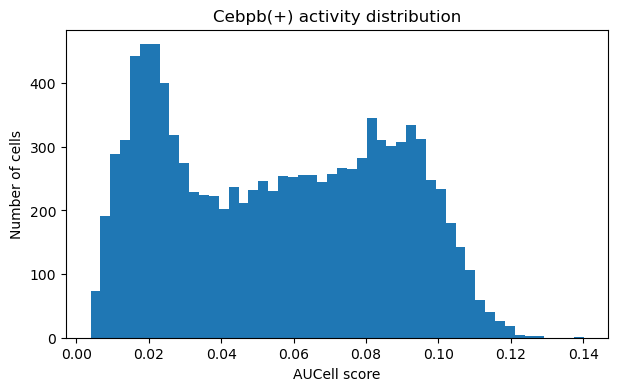

In [59]:
## Visualize the distribution of one regulon
import matplotlib.pyplot as plt


regulon = "Cebpb(+)"

plt.figure(figsize=(7, 4))

plt.hist(
    auc_matrix[regulon],
    bins=50,
)

plt.xlabel("AUCell score")
plt.ylabel("Number of cells")
plt.title(f"{regulon} activity distribution")

plt.show()


Esse gráfico mostra a distribuição da atividade do regulon entre todas as células:

* valores mais altos indicam células nas quais os genes-alvo do regulon aparecem mais próximos do topo do ranking;
* valores baixos indicam pouca recuperação dos genes-alvo;
* ele não fornece p-valores;
* ele não define automaticamente células “ativas” e “inativas”.

In [ ]:
## Visualize one regulon on the existing UMAP

# Primeiro, confira se as células estão presentes e na mesma ordem:

missing_cells = adata_scenic.obs_names.difference(
    auc_matrix.index
)

print(f"Missing cells: {len(missing_cells)}")

# O esperado é: Missing cells: 0
# Depois, adicione a matriz ao `AnnData`:

auc_matrix = auc_matrix.loc[
    adata_scenic.obs_names
].copy()

adata_scenic.obsm["X_scenic_auc"] = auc_matrix
adata_scenic.uns["scenic_regulons"] = (
    auc_matrix.columns.to_numpy()
)

# Adicione um regulon ao `obs` para visualização:

regulon = "Cebpb(+)"

adata_scenic.obs[
    f"SCENIC_{regulon}"
] = auc_matrix[regulon]

# Plote no UMAP já existente:

import scanpy as sc

sc.pl.umap(
    adata_scenic,
    color=f"SCENIC_{regulon}",
    title=f"{regulon} activity",
)


Esse gráfico usa o **UMAP original baseado na expressão gênica** e colore cada célula pelo score AUCell. Ele permite observar em quais populações o regulon está mais ativo.

A interpretação correta é:

> Cells in this region of the UMAP show higher enrichment of the target genes belonging to this regulon.

Não significa necessariamente:

> The transcription factor is more highly expressed or experimentally more active in these cells.

A atividade do regulon é inferida a partir da expressão conjunta de seus genes-alvo [Aibar, 2017; Van de Sande, 2020].

[1]: https://pmc.ncbi.nlm.nih.gov/articles/PMC5937676/?utm_source=chatgpt.com "SCENIC: Single-cell regulatory network inference and clustering"

>     
> **pySCENIC OFICIAL DOCUMENTATION STOPS HERE**
>   

# NON - OFICIAL STEPS

## Import AUCell activity into AnnData

The AUCell output contains one activity score for each regulon in each cell. The matrix is organized as cells × regulons.

The cell identifiers stored in the AUCell loom file were matched to the cell identifiers in the AnnData object. The matrix was reordered when necessary to ensure that each AUCell score was assigned to the correct cell.

The regulon activity matrix was stored in:

* `adata.obsm["X_scenic_auc"]`: cell × regulon activity matrix.
* `adata.uns["scenic_regulons"]`: names of the regulons represented in the matrix.

The AUCell score indicates whether the target genes of a regulon are highly ranked within the expression profile of a cell. It is a relative activity score and does not directly measure TF expression, TF protein abundance or DNA binding [Aibar, 2017; Van de Sande, 2020]. ([Nature][1])


In [43]:
from pathlib import Path

import loompy
import numpy as np
import pandas as pd


def ImportScenicAucell(
    adata,
    aucell_path,
    *,
    key="X_scenic_auc",
):
    """
    Import the AUCell regulon activity matrix into an AnnData object.

    The function matches the cell identifiers from the AUCell loom
    file with adata.obs_names and stores the activity matrix in .obsm.
    """

    aucell_path = Path(aucell_path)

    if not aucell_path.exists():
        raise FileNotFoundError(
            f"AUCell file not found: {aucell_path}"
        )

    # Read AUCell scores and cell identifiers from the loom file
    with loompy.connect(
        str(aucell_path),
        mode="r",
        validate=False,
    ) as loom:

        if "RegulonsAUC" not in loom.ca.keys():
            raise ValueError(
                "The loom file does not contain 'RegulonsAUC'."
            )

        if "CellID" not in loom.ca.keys():
            raise ValueError(
                "The loom file does not contain 'CellID'."
            )

        cell_ids = pd.Index(
            loom.ca["CellID"].astype(str)
        )

        auc_matrix = pd.DataFrame(
            loom.ca["RegulonsAUC"],
            index=cell_ids,
        )

    # Ensure that cell identifiers are unique
    if not auc_matrix.index.is_unique:
        raise ValueError(
            "Duplicated cell identifiers were found in the AUCell file."
        )

    adata_cells = pd.Index(
        adata.obs_names.astype(str)
    )

    # Check whether all AnnData cells are present in the AUCell output
    missing_cells = adata_cells.difference(
        auc_matrix.index
    )

    if len(missing_cells) > 0:
        raise ValueError(
            f"{len(missing_cells)} AnnData cells were not found "
            "in the AUCell output."
        )

    # Reorder the AUCell matrix to match the AnnData cell order
    auc_matrix = auc_matrix.loc[adata_cells].copy()

    # Store the activity matrix and regulon names
    adata.obsm[key] = auc_matrix

    adata.uns["scenic_regulons"] = np.asarray(
        auc_matrix.columns,
        dtype=str,
    )

    print(f"Cells imported: {auc_matrix.shape[0]}")
    print(f"Regulons imported: {auc_matrix.shape[1]}")
    print(f"Stored in adata.obsm['{key}']")

    return adata, auc_matrix

/home/tahila/miniconda3/envs/scenic_env/lib/python3.8/site-packages/loompy/bus_file.py:68: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def twobit_to_dna(twobit: int, size: int) -> str:
/home/tahila/miniconda3/envs/scenic_env/lib/python3.8/site-packages/loompy/bus_file.py:85: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def dna_to_twobit(dna: str) -> int:
/hom

In [35]:
adata_scenic, auc_matrix = ImportScenicAucell(
    adata_scenic,
    aucell_path=aucell_path,
)
adata_scenic

Cells imported: 10570
Regulons imported: 199
Stored in adata.obsm['X_scenic_auc']


AnnData object with n_obs × n_vars = 10570 × 10272
    obs: 'sample', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'doublet_score', 'predicted_doublet', 'is_doublet', 'leiden_res0.3', 'leiden_res0.4', 'leiden_res0.5', 'leiden_res0.6', 'leiden_res0.8', 'score_G0', 'score_G1', 'score_G2', 'score_G3', 'score_G4', 'score_G5a', 'score_G5b', 'score_G5c', 'aucell_G0', 'aucell_G1', 'aucell_G2', 'aucell_G3', 'aucell_G4', 'aucell_G5a', 'aucell_G5b', 'aucell_G5c', 'celltype'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'used_for_pca'
    uns: 'celltype_colors', 'hvg', 'leiden_res0.8_colors', 'log1p', 'neighbors', 'pca', 'qc_params', 'rank_gene

In [36]:
auc_matrix.head()

,Arid3a(+),Arnt(+),Atf1(+),Atf2(+),Atf3(+),Atf4(+),Bach1(+),Bcl11a(+),Bclaf1(+),Bhlhe40(+),...,Zfp712(+),Zfp768(+),Zfp770(+),Zfp790(+),Zfp87(+),Zfp994(+),Zgpat(+),Zkscan1(+),Zkscan6(+),Zscan21(+)
106988-K1,0.148176,0.0,0.000000,0.000000,0.000000,0.015578,0.001729,0.0,0.010574,0.000000,...,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
155169-K1,0.075049,0.0,0.000000,0.000000,0.004635,0.024601,0.000000,0.0,0.013783,0.000000,...,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
165809-K1,0.110700,0.0,0.021401,0.000000,0.064317,0.019949,0.005861,0.0,0.012318,0.000000,...,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
216472-K1,0.125122,0.0,0.000000,0.006184,0.082227,0.021659,0.013643,0.0,0.012524,0.015629,...,0.0,0.0,0.000000,0.0,0.051881,0.006615,0.0,0.0,0.0,0.0
247465-K1,0.120647,0.0,0.000000,0.000000,0.103571,0.021105,0.007518,0.0,0.005797,0.000000,...,0.0,0.0,0.020248,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


In [37]:
print(auc_matrix.shape)

(10570, 199)


In [38]:
adata_scenic.uns["scenic_regulons"][:20]

array(['Arid3a(+)', 'Arnt(+)', 'Atf1(+)', 'Atf2(+)', 'Atf3(+)', 'Atf4(+)',
       'Bach1(+)', 'Bcl11a(+)', 'Bclaf1(+)', 'Bhlhe40(+)', 'Bptf(+)',
       'Ccnt2(+)', 'Cebpa(+)', 'Cebpb(+)', 'Cebpd(+)', 'Cebpe(+)',
       'Cebpg(+)', 'Chd1(+)', 'Churc1(+)', 'Ctcf(+)'], dtype='<U10')

In [39]:
auc_matrix["Cebpb(+)"].head()

106988-K1    0.034614
155169-K1    0.016869
165809-K1    0.080808
216472-K1    0.093348
247465-K1    0.086198
Name: Cebpb(+), dtype: float64

## Summarize regulon activity by biological sample

AUCell provides one regulon activity score for each cell. These cell-level scores are useful for visualization and for identifying heterogeneous cell states. However, cells from the same biological sample are not independent experimental replicates.

For comparisons between experimental conditions, regulon activity should first be summarized within each biological sample. When different cell populations are present, the aggregation should also be performed separately for each cell type or cell state to avoid mixing differences in regulon activity with differences in cell composition.

For example, consider the activity of the `Cebpb(+)` regulon:

| Sample | Condition | Cell type | Cell-level AUC values | Mean AUC |
| ------ | --------- | --------- | --------------------- | -------: |
| WT1    | WT        | G4        | 0.12, 0.18, 0.20      |    0.167 |
| WT2    | WT        | G4        | 0.15, 0.14, 0.19      |    0.160 |
| KO1    | KO        | G4        | 0.30, 0.27, 0.35      |    0.307 |

The result contains one value per biological sample and cell population. These sample-level summaries can later be used for visualization and statistical comparisons.

This procedure does not create pseudobulk gene counts. It calculates a sample-level summary of cell-level AUCell scores. The AUCell score remains a relative enrichment score indicating whether regulon target genes are highly ranked within each cell [Aibar, 2017; Van de Sande, 2020]. ([PubMed Central (PMC)][1])


A tabela terá aproximadamente esta estrutura:

| Sample | Condition | Celltype | n_cells | regulon  | mean_auc |
| ------ | --------- | -------- | ------: | -------- | -------: |
| WT1    | WT        | G4       |     350 | Cebpb(+) |    0.167 |
| WT1    | WT        | G4       |     350 | Stat1(+) |    0.082 |
| WT2    | WT        | G4       |     410 | Cebpb(+) |    0.160 |

Para verificar quantas células contribuíram para cada resumo:

```python
scenic_summary[
    ["Sample", "Condition", "Celltype", "n_cells"]
].drop_duplicates()
```

É importante observar grupos com poucas células. Uma média calculada com poucas células pode ser instável e não deve ser interpretada com o mesmo grau de confiança que uma média baseada em uma população celular bem representada. Não há um cutoff universal de número mínimo de células validado para todas as análises de atividade regulatória.

[1]: https://pmc.ncbi.nlm.nih.gov/articles/PMC5937676/?utm_source=chatgpt.com "SCENIC: Single-cell regulatory network inference and clustering"


In [40]:
import numpy as np
import pandas as pd


def SummarizeScenicActivity(
    adata,
    *,
    auc_key="X_scenic_auc",
    sample_key="Sample",
    group_keys=None,
    statistic="mean",
):
    """
    Summarize cell-level AUCell scores by biological sample.

    The activity can also be summarized separately by condition,
    cell type, cell state, or other metadata columns.
    """

    if auc_key not in adata.obsm:
        raise ValueError(
            f"'{auc_key}' was not found in adata.obsm."
        )

    if sample_key not in adata.obs.columns:
        raise ValueError(
            f"'{sample_key}' was not found in adata.obs."
        )

    if group_keys is None:
        group_keys = []

    group_keys = list(group_keys)

    # Check metadata columns
    for key in group_keys:
        if key not in adata.obs.columns:
            raise ValueError(
                f"'{key}' was not found in adata.obs."
            )

    if statistic not in ["mean", "median"]:
        raise ValueError(
            "`statistic` must be either 'mean' or 'median'."
        )

    # Read the cell-by-regulon activity matrix
    auc_data = adata.obsm[auc_key]

    if isinstance(auc_data, pd.DataFrame):
        auc_matrix = auc_data.copy()
        auc_matrix.index = adata.obs_names

    else:
        # Use regulon names stored during the import step
        if "scenic_regulons" not in adata.uns:
            raise ValueError(
                "Regulon names were not found in "
                "adata.uns['scenic_regulons']."
            )

        regulon_names = adata.uns["scenic_regulons"]

        auc_matrix = pd.DataFrame(
            np.asarray(auc_data),
            index=adata.obs_names,
            columns=regulon_names,
        )

    metadata_columns = [sample_key] + group_keys
    metadata = adata.obs[metadata_columns].copy()

    # Combine metadata and AUCell scores
    activity_table = metadata.join(auc_matrix)

    # Calculate the number of cells in each sample/group
    cell_counts = (
        activity_table
        .groupby(metadata_columns, observed=True)
        .size()
        .rename("n_cells")
    )

    regulon_columns = list(auc_matrix.columns)

    # Summarize regulon activity
    grouped_activity = activity_table.groupby(
        metadata_columns,
        observed=True,
    )[regulon_columns]

    if statistic == "mean":
        summary = grouped_activity.mean()
    else:
        summary = grouped_activity.median()

    summary = summary.join(cell_counts).reset_index()

    # Convert to long format
    summary_long = summary.melt(
        id_vars=metadata_columns + ["n_cells"],
        value_vars=regulon_columns,
        var_name="regulon",
        value_name=f"{statistic}_auc",
    )

    print(
        f"Biological samples: "
        f"{summary_long[sample_key].nunique()}"
    )
    print(
        f"Regulons summarized: "
        f"{summary_long['regulon'].nunique()}"
    )
    print(
        f"Groups summarized: "
        f"{summary[metadata_columns].drop_duplicates().shape[0]}"
    )

    return summary_long

In [41]:
# Primeiro, confira os nomes das colunas:
adata_scenic.obs.columns.tolist()

# Para resumir apenas por amostra:
scenic_summary = SummarizeScenicActivity(
    adata_scenic,
    sample_key=sample_col,
)

# Para resumir separadamente por condição e estágio celular:
scenic_summary = SummarizeScenicActivity(
    adata_scenic,
    sample_key=sample_col,
    group_keys=[condition_col, celltype_col],
    statistic="mean",
)

# Substitua `"Condition"` e `"Celltype"` pelos nomes exatos presentes em `adata_scenic.obs`.

## Check the result
scenic_summary.head()

Biological samples: 4
Regulons summarized: 199
Groups summarized: 4
Biological samples: 4
Regulons summarized: 199
Groups summarized: 32


,sample,condition,celltype,n_cells,regulon,mean_auc
0,K1,KO,G3,172,Arid3a(+),0.130463
1,K1,KO,G2,433,Arid3a(+),0.085883
2,K1,KO,G5a,394,Arid3a(+),0.119533
3,K1,KO,G4,580,Arid3a(+),0.137063
4,K1,KO,G5b,56,Arid3a(+),0.112870


## Plot regulon activity by biological sample


> **NOTE:** Sample-level aggregation and statistical comparison of AUCell scores are not part of the original SCENIC/pySCENIC pipeline. The official workflow ends after regulon inference with GRNBoost2, motif-based pruning with cisTarget, and per-cell regulon activity estimation with AUCell [Aibar, 2017; Van de Sande, 2020].
>
> The downstream aggregation of AUCell scores by biological sample was included here only as an exploratory strategy to avoid treating individual cells as independent biological replicates. However, there is no established SCENIC standard or sufficiently validated method for differential testing of sample-aggregated AUCell scores. Therefore, these results should be interpreted descriptively and should not be considered part of the validated SCENIC workflow.


### Plot sample-level regulon activity

Regulon activity was visualized using the AUCell scores summarized for each biological sample and cell population.

Each point in the plot represents one biological sample. Cells from the same sample were not plotted as independent experimental replicates because they share the same biological origin. Treating individual cells as independent replicates can underestimate biological variability and produce misleading comparisons between conditions [Zimmerman, 2021].

For each condition, the plot shows:

* Individual sample-level mean AUCell scores.
* The mean activity across biological samples.
* The standard deviation between biological samples.

The plot is descriptive and does not perform a statistical test. A higher sample-level AUCell score indicates that the target genes of the regulon tend to be more highly ranked in the cells from that sample and cell population. It does not directly measure TF expression, TF protein abundance or DNA binding [Aibar, 2017; Van de Sande, 2020]. ([Nature][1])

The function returns `cebpb_data`, which contains exactly the sample-level values used in the figure:

```python
cebpb_data
```

The next step is the statistical comparison of regulon activity between conditions using biological samples as the experimental units.

[1]: https://www.nature.com/articles/s41596-020-0336-2?utm_source=chatgpt.com "A scalable SCENIC workflow for single-cell gene regulatory network analysis | Nature Protocols"


In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def PlotScenicActivity(
    scenic_summary,
    regulon,
    condition_key,
    *,
    sample_key="Sample",
    value_key="mean_auc",
    group_filters=None,
    order=None,
    figsize=(6, 4),
    jitter=0.08,
    random_state=42,
):
    """
    Plot sample-level AUCell activity for one regulon.

    Each point represents one biological sample. The plot also shows
    the mean and standard deviation across samples in each condition.
    """

    required_columns = {
        sample_key,
        condition_key,
        "regulon",
        value_key,
    }

    missing_columns = required_columns.difference(
        scenic_summary.columns
    )

    if missing_columns:
        raise ValueError(
            f"Missing columns: {sorted(missing_columns)}"
        )

    # Select the requested regulon
    plot_data = scenic_summary.loc[
        scenic_summary["regulon"] == regulon
    ].copy()

    # Filter by cell type, cell state, tissue, or other metadata
    if group_filters is not None:
        for column, value in group_filters.items():

            if column not in plot_data.columns:
                raise ValueError(
                    f"Column '{column}' was not found."
                )

            plot_data = plot_data.loc[
                plot_data[column] == value
            ].copy()

    if plot_data.empty:
        raise ValueError(
            "No data were found for the selected regulon and filters."
        )

    # Each sample should have only one value per condition
    duplicated_samples = plot_data.duplicated(
        subset=[sample_key, condition_key],
        keep=False,
    )

    if duplicated_samples.any():
        raise ValueError(
            "More than one value was found per sample and condition. "
            "Use `group_filters` to select one cell population."
        )

    # Define the order of conditions
    if order is None:
        order = list(
            pd.unique(plot_data[condition_key])
        )

    unknown_conditions = set(
        plot_data[condition_key]
    ).difference(order)

    if unknown_conditions:
        raise ValueError(
            f"Conditions missing from `order`: "
            f"{sorted(unknown_conditions)}"
        )

    rng = np.random.default_rng(random_state)

    fig, ax = plt.subplots(figsize=figsize)

    for position, condition in enumerate(order):

        condition_data = plot_data.loc[
            plot_data[condition_key] == condition
        ].copy()

        values = condition_data[value_key].to_numpy(
            dtype=float
        )

        # Add small horizontal jitter to separate sample points
        x_positions = rng.normal(
            loc=position,
            scale=jitter,
            size=len(values),
        )

        ax.scatter(
            x_positions,
            values,
            s=55,
            zorder=3,
        )

        mean_value = values.mean()

        # SD is only meaningful when at least two samples are present
        sd_value = (
            values.std(ddof=1)
            if len(values) > 1
            else 0
        )

        ax.errorbar(
            position,
            mean_value,
            yerr=sd_value,
            fmt="_",
            markersize=20,
            capsize=5,
            linewidth=2,
            zorder=4,
        )

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)

    ax.set_xlabel(condition_key)
    ax.set_ylabel("Mean AUCell score")
    ax.set_title(f"{regulon} activity")

    plt.tight_layout()

    return fig, ax, plot_data


In [44]:
## Check the regulon name
[
    regulon
    for regulon in scenic_summary["regulon"].unique()
    if "Cebpb" in regulon
]

['Cebpb(+)']

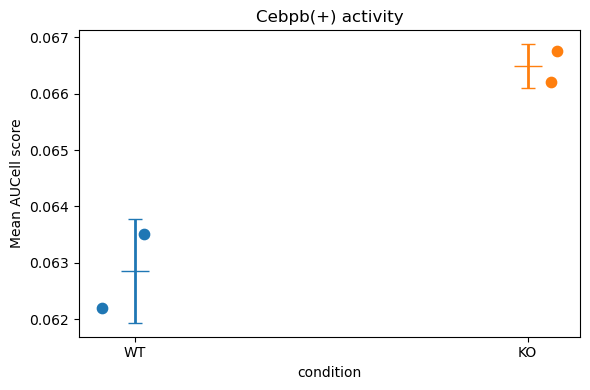

In [46]:
## Apply for one cell population
fig, ax, cebpb_data = PlotScenicActivity(
    scenic_summary,
    regulon="Cebpb(+)",
    condition_key=condition_col,
    sample_key=sample_col,
    group_filters={
        celltype_col: "G4",
    },
    order=["WT", "KO"],
)

# Replace `"Celltype"`, `"G4"`, `"Condition"` and the condition names with the exact values in your table.


In [47]:
cebpb_data

,sample,condition,celltype,n_cells,regulon,mean_auc
419,K1,KO,G4,580,Cebpb(+),0.066209
427,K2,KO,G4,876,Cebpb(+),0.066761
435,W1,WT,G4,778,Cebpb(+),0.063505
443,W2,WT,G4,690,Cebpb(+),0.062207


In [50]:
## Por exemplo, comparando KO contra WT dentro de G4:

scenic_comparison = TestScenicActivity(
    scenic_summary,
    condition_key=condition_col,
    reference_condition=normal_condition,
    test_condition=compare_condition,
    sample_key=sample_col,
    group_filters={
        celltype_col: "G4",
    },
)

Reference condition: WT
Test condition: KO
Biological samples: 2 vs 2
Regulons compared: 199

Interpret mean differences as descriptive results.


A diferença será calculada como:

```text
KO − WT
```

Portanto:

```text
mean_difference > 0
```

significa maior atividade no KO, enquanto:

```text
mean_difference < 0
```

significa menor atividade no KO.

In [51]:
## View the strongest differences
scenic_comparison.head(20)

,regulon,n_WT,n_KO,mean_WT,mean_KO,mean_difference,statistic,pvalue,padj,abs_mean_difference
0,Fosb(+),2,2,0.267785,0.311088,0.043302,NaN,NaN,NaN,0.043302
1,Junb(+),2,2,0.102454,0.114062,0.011608,NaN,NaN,NaN,0.011608
2,Jdp2(+),2,2,0.264204,0.255706,-0.008498,NaN,NaN,NaN,0.008498
3,Fosl2(+),2,2,0.134922,0.141474,0.006552,NaN,NaN,NaN,0.006552
4,Klf6(+),2,2,0.138619,0.145163,0.006544,NaN,NaN,NaN,0.006544
5,Lhx1(+),2,2,0.083872,0.090389,0.006518,NaN,NaN,NaN,0.006518
6,Irf2(+),2,2,0.104183,0.110676,0.006493,NaN,NaN,NaN,0.006493
7,Rara(+),2,2,0.106783,0.112648,0.005865,NaN,NaN,NaN,0.005865
8,Fosl1(+),2,2,0.019504,0.024558,0.005054,NaN,NaN,NaN,0.005054
9,Klf2(+),2,2,0.144437,0.149415,0.004978,NaN,NaN,NaN,0.004978


In [52]:
## Show only regulons with increased activity in KO
scenic_comparison.loc[
    scenic_comparison["mean_difference"] > 0
].head(20)


,regulon,n_WT,n_KO,mean_WT,mean_KO,mean_difference,statistic,pvalue,padj,abs_mean_difference
0,Fosb(+),2,2,0.267785,0.311088,0.043302,NaN,NaN,NaN,0.043302
1,Junb(+),2,2,0.102454,0.114062,0.011608,NaN,NaN,NaN,0.011608
3,Fosl2(+),2,2,0.134922,0.141474,0.006552,NaN,NaN,NaN,0.006552
4,Klf6(+),2,2,0.138619,0.145163,0.006544,NaN,NaN,NaN,0.006544
5,Lhx1(+),2,2,0.083872,0.090389,0.006518,NaN,NaN,NaN,0.006518
6,Irf2(+),2,2,0.104183,0.110676,0.006493,NaN,NaN,NaN,0.006493
7,Rara(+),2,2,0.106783,0.112648,0.005865,NaN,NaN,NaN,0.005865
8,Fosl1(+),2,2,0.019504,0.024558,0.005054,NaN,NaN,NaN,0.005054
9,Klf2(+),2,2,0.144437,0.149415,0.004978,NaN,NaN,NaN,0.004978
11,Fos(+),2,2,0.086054,0.090881,0.004827,NaN,NaN,NaN,0.004827


In [53]:
## Show only regulons with decreased activity in KO
scenic_comparison.loc[
    scenic_comparison["mean_difference"] < 0
].head(20)

,regulon,n_WT,n_KO,mean_WT,mean_KO,mean_difference,statistic,pvalue,padj,abs_mean_difference
2,Jdp2(+),2,2,0.264204,0.255706,-0.008498,NaN,NaN,NaN,0.008498
10,Ets1(+),2,2,0.126858,0.121931,-0.004927,NaN,NaN,NaN,0.004927
20,Klf7(+),2,2,0.128326,0.124973,-0.003353,NaN,NaN,NaN,0.003353
21,Mxi1(+),2,2,0.093797,0.090605,-0.003192,NaN,NaN,NaN,0.003192
22,Cebpe(+),2,2,0.109216,0.106042,-0.003174,NaN,NaN,NaN,0.003174
23,Erg(+),2,2,0.074398,0.071333,-0.003066,NaN,NaN,NaN,0.003066
29,Ikzf1(+),2,2,0.061070,0.059118,-0.001952,NaN,NaN,NaN,0.001952
30,Nfe2(+),2,2,0.205863,0.203952,-0.001911,NaN,NaN,NaN,0.001911
31,Arid3a(+),2,2,0.142544,0.140698,-0.001847,NaN,NaN,NaN,0.001847
32,Ltf(+),2,2,0.068453,0.066708,-0.001744,NaN,NaN,NaN,0.001744


# MULTIPLE EXECUTIONS

## Data preparation

In [ ]:
from pathlib import Path




In [ ]:
## Data filtering 
adata_scenic = PrepareScenicInput(
    adata,
    counts_layer=counts_layer,
    sample_key=sample_col,
    samples=None,
    tfs=tfs,
)

## Loom export
loom_path = ExportScenicLoom(
    adata_scenic,
    loom_path=loom_path,
)

Cells selected: 10570
Minimum cells per gene: 106
Minimum total counts per gene: 318
Genes retained: 10272 of 27992
TFs retained: 903 of 1860
File already exists: /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/input/scenic_input.loom


## Repeated pySCENIC runs for consensus regulon inference


Sim. Agora começamos o primeiro incremento real: **repetir o pySCENIC para construir regulons consensuais**, em vez de confiar em uma única execução.

O ponto importante é que **não precisamos modificar `RunScenicGrn` nem `RunScenicCtx`**. Podemos reutilizá-las exatamente como estão, criando uma pasta separada para cada run:

```text
runs/
├── run_001/
│   ├── adjacencies.tsv
│   └── regulons.csv
├── run_002/
│   ├── adjacencies.tsv
│   └── regulons.csv
...
```

E também **não vamos rodar AUCell em cada run**. Em [Garner, 2023], eles repetiram GRNBoost2 + cisTarget 100 vezes, construíram os regulons de alta confiança e **só então** recalcularam AUCell usando esses regulons consensuais. ([Nature][1])

Por enquanto, eu faria **10 runs como piloto**. Depois verificamos tempo, arquivos e estabilidade e, estando tudo certo, aumentamos para 100.

---

GRNBoost2 is stochastic, meaning that independent pySCENIC runs can generate slightly different TF-target associations and regulons. Therefore, relying on a single run may include regulatory relationships that are not consistently recovered.

To evaluate the stability of the inferred gene regulatory network, pySCENIC was run repeatedly using different random seeds. Each run independently performs:

1. GRNBoost2 inference of candidate TF-target associations.
2. cisTarget motif enrichment and regulon pruning.

AUCell is not calculated at this stage. After all runs are completed, recurrent regulons and recurrent TF-target associations will be identified and used to construct a consensus regulon set. AUCell will then be recalculated using only these high-confidence regulons.

This strategy follows the approach used by Garner et al., who performed 100 pySCENIC runs because GRNBoost2 can return different regulons and target genes across runs. They defined high-confidence regulons as regulons detected in more than 80% of runs and containing at least five high-confidence target genes. A high-confidence target gene was defined as a target found within the same regulon in more than 80% of runs [Garner, 2023].

Repeated SCENIC inference has also been used in other single-cell studies to evaluate regulatory-network reproducibility [Sanchís-Calleja, 2025].

For this analysis, an initial set of 10 runs was performed as a computational pilot before increasing the analysis to 100 runs.


In [6]:
## Function

#Esta função apenas controla as execuções. Ela chama as duas funções que você já tem:
#* `RunScenicGrn()`
#* `RunScenicCtx()`


from pathlib import Path
import pandas as pd


def RunRepeatedScenic(
    loom_path,
    tf_path,
    ranking_db_paths,
    motif_path,
    output_dir,
    *,
    n_runs=10,
    num_workers=3,
    base_seed=42,
):
    """
    Run GRNBoost2 and cisTarget multiple times using different seeds.

    Each run is stored in a separate directory. AUCell is not run here
    because it will be calculated later using the consensus regulons.
    """

    output_dir = Path(output_dir)
    runs_dir = output_dir / "runs"

    runs_dir.mkdir(parents=True, exist_ok=True)

    run_summary = []

    for run_number in range(1, n_runs + 1):

        seed = base_seed + run_number - 1

        run_dir = runs_dir / f"run_{run_number:03d}"

        print("\n" + "=" * 60)
        print(
            f"Run {run_number}/{n_runs} | "
            f"Seed: {seed}"
        )
        print("=" * 60)

        # Step 1: infer TF-target associations
        adjacency_path = RunScenicGrn(
            loom_path=loom_path,
            tf_path=tf_path,
            output_dir=run_dir,
            num_workers=num_workers,
            seed=seed,
        )

        # Step 2: prune the network using cisTarget
        regulons_path = RunScenicCtx(
            adjacency_path=adjacency_path,
            ranking_db_paths=ranking_db_paths,
            motif_path=motif_path,
            loom_path=loom_path,
            output_dir=run_dir,
            num_workers=num_workers,
        )

        run_summary.append(
            {
                "run": run_number,
                "seed": seed,
                "adjacency_path": str(adjacency_path),
                "regulons_path": str(regulons_path),
            }
        )

    run_summary = pd.DataFrame(run_summary)

    # Save a manifest with all runs
    summary_path = runs_dir / "run_summary.csv"

    run_summary.to_csv(
        summary_path,
        index=False,
    )

    print("\nRepeated SCENIC inference completed.")
    print(f"Runs completed: {len(run_summary)}")
    print(f"Summary: {summary_path}")

    return run_summary

In [21]:
## Primeiro teste: somente 10 runs
run_summary = RunRepeatedScenic(
    loom_path=loom_path,
    tf_path=tf_path,
    ranking_db_paths=ranking_db_paths,
    motif_path=motif_path,
    output_dir=output_dir,
    n_runs=3,
    num_workers=10,
    base_seed=42,
)

run_summary


Run 1/3 | Seed: 42
Running GRNBoost2...
pyscenic grn /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/input/scenic_input.loom /home/tahila/0.resources/scenic/allTFs_mm.txt --method grnboost2 --output /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/runs/run_001/adjacencies.tsv --num_workers 10 --seed 42


/home/tahila/miniconda3/envs/scenic_env/lib/python3.8/site-packages/loompy/bus_file.py:68: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def twobit_to_dna(twobit: int, size: int) -> str:
/home/tahila/miniconda3/envs/scenic_env/lib/python3.8/site-packages/loompy/bus_file.py:85: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def dna_to_twobit(dna: str) -> int:
/hom

preparing dask client
parsing input
creating dask graph
10 partitions
computing dask graph


/home/tahila/miniconda3/envs/scenic_env/lib/python3.8/site-packages/distributed/client.py:3108: UserWarning: Sending large graph of size 108.82 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


not shutting down client, client was created externally
finished


...

/home/tahila/miniconda3/envs/scenic_env/lib/python3.8/site-packages/distributed/client.py:3108: UserWarning: Sending large graph of size 108.82 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


not shutting down client, client was created externally
finished



2026-08-07 11:32:52,562 - pyscenic.cli.pyscenic - INFO - Writing results to file.



Adjacency file created: /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/runs/run_003/adjacencies.tsv
Running cisTarget...
pyscenic ctx /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/runs/run_003/adjacencies.tsv /home/tahila/0.resources/scenic/mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather /home/tahila/0.resources/scenic/mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather --annotations_fname /home/tahila/0.resources/scenic/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl --expression_mtx_fname /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/input/scenic_input.loom --mode custom_multiprocessing --output /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/runs/run_003/regulons.csv --num_workers 10

Regulon file created: /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/runs/run_003/regulons.csv
Log file created: /media/ta

,run,seed,adjacency_path,regulons_path
0,1,42,/media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/0...,/media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/0...
1,2,43,/media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/0...,/media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/0...
2,3,44,/media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/0...,/media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/0...


Você deverá obter algo semelhante a:

| run | seed | adjacency_path              | regulons_path            |
| --: | ---: | --------------------------- | ------------------------ |
|   1 |   42 | .../run_001/adjacencies.tsv | .../run_001/regulons.csv |
|   2 |   43 | .../run_002/adjacencies.tsv | .../run_002/regulons.csv |
|   3 |   44 | ...                         | ...                      |
| ... |  ... | ...                         | ...                      |
|  10 |   51 | ...                         | ...                      |

---

### O que exatamente estará variando?

A matriz é **a mesma** em todos os runs:

```text
same cells
same genes
same TF list
same cisTarget databases
```

O que muda é:

```text
GRNBoost2 random seed
```

Por exemplo:

```text
run_001 seed 42
run_002 seed 43
run_003 seed 44
...
```

Isso permite perguntar posteriormente:

> `Cebpb → Il1b` apareceu em quantas execuções?

Exemplo:

```text
Cebpb → Il1b       98/100
Cebpb → Cxcl2      91/100
Cebpb → GeneX      17/100
```

A primeira associação seria extremamente estável; a última, muito menos.

Mas atenção: o critério de Garner não é simplesmente contar as arestas do `adjacencies.tsv`. Para ser **high-confidence target**, o gene precisa aparecer no **regulon depois do cisTarget** em >80% das execuções. [Garner, 2023] ([Nature][1])

Então nosso consenso será construído a partir de:

```text
regulons.csv
```

e não apenas:

```text
adjacencies.tsv
```

---

### Por que primeiro 10 e depois 100?

O número **100** tem precedente experimental publicado [Garner, 2023; Sanchís-Calleja, 2025], mas não é um parâmetro matematicamente obrigatório do SCENIC. Garner escolheu 100 runs e depois usou frequência >80% como critério de alta confiança. ([Nature][1])

Não há evidência suficiente para afirmar que **100 seja universalmente o número ótimo de execuções**.

Por isso, para o seu pipeline eu prefiro:

```text
10 runs
    ↓
verificar se tudo funciona
    ↓
medir tempo e armazenamento
    ↓
100 runs
    ↓
avaliar estabilidade/convergência
```

Depois inclusive poderemos perguntar:

```text
O consenso com 20 runs
é praticamente igual ao de 50?
E ao de 100?
```

Isso nos dará uma avaliação empírica da estabilidade **do seu próprio conjunto de dados**, em vez de simplesmente assumir que 100 é um número mágico.

**Neste passo, faça apenas as 10 execuções.** O próximo passo será ler os `regulons.csv` dessas execuções e descobrir exatamente como extrair `TF → target` deles antes de construir qualquer consenso. [Garner, 2023; Sanchís-Calleja, 2025]. ([Nature][1])

[1]: https://www.nature.com/articles/s41590-023-01575-1 "Single-cell analysis of human MAIT cell transcriptional, functional and clonal diversity | Nature Immunology"


In [22]:
run_summary.head()

,run,seed,adjacency_path,regulons_path
0,1,42,/media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/0...,/media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/0...
1,2,43,/media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/0...,/media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/0...
2,3,44,/media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/0...,/media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/0...


### Build consensus regulons from repeated pySCENIC runs


Sim. **Dá para juntar, e faz mais sentido.**

Para o seu pipeline simples, eu faria uma única função que:

1. lê todos os `regulons.csv`;
2. extrai regulons e targets;
3. calcula recorrência por regulon;
4. calcula recorrência por TF–target;
5. já aplica o critério de consenso de [Garner, 2023];
6. retorna:

   * tabela de regulons;
   * tabela de targets;
   * regulons consensuais.

Repeated pySCENIC runs were summarized to identify regulons and target genes that were consistently recovered across independent runs.

For each transcription factor, two recurrence measures were calculated:

* **Regulon recurrence:** fraction of runs in which the regulon was recovered.
* **Target recurrence:** fraction of runs in which a target gene was recovered within the same regulon.

Following Garner et al., high-confidence regulons were defined as regulons detected in more than 80% of runs and containing at least five high-confidence target genes. High-confidence target genes were those recovered within the same regulon in more than 80% of runs [Garner, 2023].

For the initial 10-run pilot, these thresholds are used only to inspect the behavior of the workflow. Final consensus regulons should be defined after the full repeated-run analysis.

In [27]:
## Function

from pathlib import Path
import pandas as pd
from pyscenic.utils import load_motifs
from pyscenic.prune import df2regulons


def BuildScenicConsensus(
    run_summary,
    *,
    recurrence_threshold=0.80,
    min_targets=5,
):
    """
    Build consensus regulons from repeated pySCENIC runs.

    Returns:
        regulon_frequency
        target_frequency
        consensus_targets
        consensus_regulons
    """

    all_targets = []

    # Read regulons from each run
    for _, row in run_summary.iterrows():

        run = row["run"]
        regulons_path = Path(row["regulons_path"])

        motifs = load_motifs(
            str(regulons_path)
        )

        regulons = df2regulons(
            motifs
        )

        for regulon in regulons:

            tf = regulon.transcription_factor

            for target in regulon.gene2weight:

                if target == tf:
                    continue

                all_targets.append(
                    {
                        "run": run,
                        "regulon": regulon.name,
                        "TF": tf,
                        "target": target,
                    }
                )

    regulon_targets = pd.DataFrame(
        all_targets
    )

    n_runs = run_summary["run"].nunique()

    # Regulon recurrence
    regulon_frequency = (
        regulon_targets[
            ["run", "regulon", "TF"]
        ]
        .drop_duplicates()
        .groupby(
            ["regulon", "TF"],
            observed=True,
        )
        .size()
        .reset_index(name="n_runs")
    )

    regulon_frequency["frequency"] = (
        regulon_frequency["n_runs"] / n_runs
    )

    # Target recurrence
    target_frequency = (
        regulon_targets[
            ["run", "regulon", "TF", "target"]
        ]
        .drop_duplicates()
        .groupby(
            ["regulon", "TF", "target"],
            observed=True,
        )
        .size()
        .reset_index(name="n_runs")
    )

    target_frequency["frequency"] = (
        target_frequency["n_runs"] / n_runs
    )

    # High-confidence targets
    consensus_targets = target_frequency.loc[
        target_frequency["frequency"]
        > recurrence_threshold
    ].copy()

    # Count high-confidence targets per regulon
    target_counts = (
        consensus_targets
        .groupby(
            ["regulon", "TF"],
            observed=True,
        )
        .size()
        .reset_index(
            name="n_consensus_targets"
        )
    )

    # Join with regulon recurrence
    consensus_regulons = (
        regulon_frequency
        .merge(
            target_counts,
            on=["regulon", "TF"],
            how="left",
        )
    )

    consensus_regulons[
        "n_consensus_targets"
    ] = (
        consensus_regulons[
            "n_consensus_targets"
        ]
        .fillna(0)
        .astype(int)
    )

    # Apply Garner et al. criteria
    consensus_regulons = consensus_regulons.loc[
        (
            consensus_regulons["frequency"]
            > recurrence_threshold
        )
        & (
            consensus_regulons[
                "n_consensus_targets"
            ]
            >= min_targets
        )
    ].copy()

    # Keep only targets belonging to consensus regulons
    consensus_targets = consensus_targets.merge(
        consensus_regulons[
            ["regulon", "TF"]
        ],
        on=["regulon", "TF"],
        how="inner",
    )

    print(f"Runs analyzed: {n_runs}")
    print(
        f"Consensus regulons: "
        f"{len(consensus_regulons)}"
    )
    print(
        f"Consensus TF-target pairs: "
        f"{len(consensus_targets)}"
    )

    return (
        regulon_frequency,
        target_frequency,
        consensus_targets,
        consensus_regulons,
    )


In [33]:
(
    regulon_frequency,
    target_frequency,
    consensus_targets,
    consensus_regulons,
) = BuildScenicConsensus(
    run_summary,
    recurrence_threshold=0.80,
    min_targets=5,
)

regulon_frequency.to_csv(output_dir / "regulon_frequency.csv", index=False,)
target_frequency.to_csv(output_dir / "target_frequency.csv", index=False,)
consensus_targets.to_csv(output_dir / "consensus_targets.csv", index=False,)
consensus_regulons.to_csv(output_dir / "consensus_regulons.csv", index=False,)

Create regulons from a dataframe of enriched features.
Additional columns saved: []
Create regulons from a dataframe of enriched features.
Additional columns saved: []
Create regulons from a dataframe of enriched features.
Additional columns saved: []
Runs analyzed: 3
Consensus regulons: 65
Consensus TF-target pairs: 9483


In [29]:
regulon_frequency

,regulon,TF,n_runs,frequency
0,Acaa1a(+),Acaa1a,1,0.333333
1,Aebp2(+),Aebp2,1,0.333333
2,Arid3a(+),Arid3a,3,1.000000
3,Arid5b(+),Arid5b,1,0.333333
4,Arnt(+),Arnt,1,0.333333
...,...,...,...,...
273,Zkscan1(+),Zkscan1,1,0.333333
274,Zkscan6(+),Zkscan6,1,0.333333
275,Zscan21(+),Zscan21,1,0.333333
276,Zscan29(+),Zscan29,1,0.333333


In [30]:
target_frequency

,regulon,TF,target,n_runs,frequency
0,Acaa1a(+),Acaa1a,Arid5b,1,0.333333
1,Acaa1a(+),Acaa1a,Cenpj,1,0.333333
2,Acaa1a(+),Acaa1a,Dleu2,1,0.333333
3,Acaa1a(+),Acaa1a,Dock10,1,0.333333
4,Acaa1a(+),Acaa1a,Gm44505,1,0.333333
...,...,...,...,...,...
70085,Zxdb(+),Zxdb,Ss18l1,1,0.333333
70086,Zxdb(+),Zxdb,Tmc4,1,0.333333
70087,Zxdb(+),Zxdb,Ttc30a1,1,0.333333
70088,Zxdb(+),Zxdb,Zbed6,1,0.333333


In [31]:
consensus_targets.head(20)

,regulon,TF,target,n_runs,frequency
0,Arid3a(+),Arid3a,Actn1,3,1.0
1,Arid3a(+),Arid3a,Cd46,3,1.0
2,Arid3a(+),Arid3a,Hmgb2,3,1.0
3,Arid3a(+),Arid3a,Lcp1,3,1.0
4,Arid3a(+),Arid3a,Nedd9,3,1.0
5,Arid3a(+),Arid3a,Nfatc1,3,1.0
6,Arid3a(+),Arid3a,Svil,3,1.0
7,Atf3(+),Atf3,Acod1,3,1.0
8,Atf3(+),Atf3,Agpat4,3,1.0
9,Atf3(+),Atf3,Ccl4,3,1.0


In [32]:
consensus_regulons.head(20)

,regulon,TF,n_runs,frequency,n_consensus_targets
2,Arid3a(+),Arid3a,3,1.0,7
8,Atf3(+),Atf3,3,1.0,7
9,Atf4(+),Atf4,3,1.0,7
17,Bclaf1(+),Bclaf1,3,1.0,407
21,Cebpa(+),Cebpa,3,1.0,8
22,Cebpb(+),Cebpb,3,1.0,207
23,Cebpd(+),Cebpd,3,1.0,32
24,Cebpe(+),Cebpe,3,1.0,158
25,Cebpg(+),Cebpg,3,1.0,6
26,Chd1(+),Chd1,3,1.0,12


## Export consensus regulons

A próxima etapa é **transformar os regulons consensuais em um arquivo que o AUCell possa usar** e então recalcular o AUCell **uma única vez** com esses regulons finais.

E aqui precisamos de uma pequena adaptação do que fizemos: `BuildScenicConsensus()` atualmente retorna as tabelas, mas não salva os regulons consensuais em formato de entrada para AUCell.

A solução mais simples é salvar um arquivo **GMT**, que contém:

```text
regulon → lista de genes-alvo consensuais
```

Isso é compatível com o AUCell/pySCENIC. Em [Garner, 2023], depois das 100 execuções, as células foram novamente pontuadas por AUCell usando **somente os high-confidence target genes** dos regulons consensuais. [Garner, 2023; Van de Sande, 2020]. ([Nature][1])

After repeated pySCENIC inference, high-confidence regulons were defined based on their recurrence across runs.

Following Garner et al., a high-confidence regulon was required to:

* Be recovered in more than 80% of pySCENIC runs.
* Contain at least five high-confidence target genes.
* Include only target genes recovered within the same regulon in more than 80% of runs.

The final consensus regulons were exported as gene signatures in GMT format. Each signature contains one transcription factor regulon and its high-confidence target genes.

AUCell was then recalculated using only these consensus regulons. Therefore, the final regulon activity matrix is based on regulatory relationships that were consistently recovered across repeated independent pySCENIC runs rather than on a single GRNBoost2 run [Garner, 2023].

AUCell ranks genes within each cell and evaluates whether the high-confidence target genes of each regulon are enriched near the top of the ranking. The resulting matrix contains one activity score for each consensus regulon in each cell [Aibar, 2017; Van de Sande, 2020].

In [35]:
from pathlib import Path

def ExportConsensusRegulons(
    consensus_targets,
    output_dir,
):
    """
    Export consensus regulons to GMT format for AUCell.

    Each regulon is stored with its high-confidence target genes.
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    gmt_path = output_dir / "consensus_regulons.gmt"

    with open(gmt_path, "w") as file:

        for regulon, data in consensus_targets.groupby("regulon"):

            # Get unique high-confidence target genes
            targets = sorted(
                data["target"].unique()
            )

            # GMT format:
            # regulon name | description | target genes
            line = "\t".join(
                [
                    regulon,
                    regulon,
                    *targets,
                ]
            )

            file.write(line + "\n")

    print(
        f"Consensus regulons exported: "
        f"{consensus_targets['regulon'].nunique()}"
    )

    print(f"Saved to: {gmt_path}")

    return gmt_path

In [36]:
consensus_dir = output_dir / "consensus"
consensus_regulons_path = ExportConsensusRegulons(
    consensus_targets,
    output_dir=consensus_dir,
)

with open(consensus_regulons_path) as file:
    for _ in range(3):
        print(file.readline())

Consensus regulons exported: 65
Saved to: /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/consensus/consensus_regulons.gmt
Arid3a(+)	Arid3a(+)	Actn1	Cd46	Hmgb2	Lcp1	Nedd9	Nfatc1	Svil

Atf3(+)	Atf3(+)	Acod1	Agpat4	Ccl4	Cd74	Il1rn	Metrnl	Nr4a2

Atf4(+)	Atf4(+)	9430015G10Rik	Egr1	Gm14023	Pex12	Rabgef1	Slc25a33	Tmem29



## Recalculate AUCell

A estrutura ficará:

```text
output/
├── runs/
│   ├── run_001/
│   ├── run_002/
│   └── ...
│
└── consensus/
    ├── consensus_regulons.gmt
    ├── aucell_output.loom
    └── aucell.log
```

### Por que não usamos os `importance` do GRNBoost2 aqui?

Porque o consenso combina resultados de muitas execuções. O que estamos mantendo agora é:

```text
TF
  ↓
target consistently recovered
```

e não uma importância específica de uma única execução.

O AUCell trabalha fundamentalmente com a **identidade dos genes pertencentes ao regulon e seu ranking dentro de cada célula**. [Van de Sande, 2020].

[Garner, 2023] diz explicitamente que as células foram pontuadas usando os high-confidence regulons **“including only high-confidence target genes”**. Portanto, esta é exatamente a informação que queremos preservar no GMT. ([Nature][1])

Depois que esse AUCell terminar, teremos finalmente a **matriz de atividade baseada nos regulons consensuais**, que será o ponto de partida para RSS, heatmaps, z-score e as demais análises planejadas.

[1]: https://www.nature.com/articles/s41590-023-01575-1?utm_source=chatgpt.com "Single-cell analysis of human MAIT cell transcriptional, functional and clonal diversity | Nature Immunology"


In [41]:
consensus_aucell_path = RunScenicAucell(
    loom_path=loom_path,
    regulons_path=consensus_regulons_path,
    output_dir=consensus_dir,
    num_workers=10,
    auc_threshold=0.05,
    seed=42,
)

Running AUCell...
pyscenic aucell /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/input/scenic_input.loom /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/consensus/consensus_regulons.gmt --output /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/consensus/aucell_output.loom --num_workers 10 --auc_threshold 0.05 --seed 42

AUCell output created: /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/consensus/aucell_output.loom
Log file created: /media/tahila/DADOS/HD/2605_scNeu/scNeuFfar2/08sx.scNeuFfar2_scenic/output/consensus/aucell.log


## Import and export consensus regulon activity

The consensus AUCell results were imported into the AnnData object using the previously defined `ImportScenicAucell()` function.

The cell-by-regulon AUCell activity matrix was stored in `adata.obsm["X_scenic_auc"]` to facilitate downstream analyses together with the existing single-cell metadata.

The same AUCell matrix was also exported as a CSV file to provide a simple tabular representation of the final pySCENIC regulon activity scores.

No additional transformation or normalization was applied during this step. The values stored in AnnData and exported to CSV correspond to the AUCell scores calculated from the consensus regulons [Aibar, 2017; Van de Sande, 2020].

In [ ]:
# Primeiro importe o AUCell consensual:
adata_scenic, auc_table = ImportScenicAucell(
    adata_scenic,
    consensus_aucell_path,
)

print(adata_scenic.obsm["X_scenic_auc"].shape)

auc_table.to_csv(
    consensus_dir / "consensus_auc_matrix.csv"
)

Cells imported: 10570
Regulons imported: 65
Stored in adata.obsm['X_scenic_auc']
(10570, 65)


Se `X_scenic_auc` estiver armazenado como `DataFrame`, isso já mantém:

* linhas = células;
* colunas = regulons;
* valores = AUCell.

No final, eu manteria estes dois resultados principais:

```text
adata_scenic
└── obsm["X_scenic_auc"]
    └── análise downstream em Python/Scanpy

consensus_auc_matrix.csv
└── tabela independente células × regulons
```

O `.loom` original também deve ser mantido como output do pySCENIC, mas **não precisamos continuar trabalhando diretamente nele**.

Depois disso, aí sim podemos passar para a primeira análise downstream dos regulons — e antes de escolher RSS, heatmap etc., vale definir qual dessas análises publicadas responde melhor à sua pergunta biológica. [Aibar, 2017; Van de Sande, 2020].
